Código adaptado de:

[1] Aurélien Géron, Hands-On Machine Learning with Scikit-Learn: Concepts, Tools and Techniques to Build Intelligent Systems, Keras & tensorFlow, Third Edition, O'Reilly, 2023.

# Laboratório 2B: DCGAN

# Tarefa (em duplas)

**Investigar o efeito da capacidade das redes, da taxa de aprendizado e do otimizador em uma DCGAN treinada com dígitos MNIST**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Substitua o conjunto *Fashion-MNIST* pelo conjunto de dígitos *MNIST*, disponível em [`torchvision.datasets`](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST):

```python
training_data = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_data     = datasets.MNIST(root="data", train=False, download=True, transform=transform)
```

**Obs.**: mantenha a normalização para o intervalo [-1, 1] já usada no `transform`, pois ela é compatível com a `Tanh` na saída do gerador.

2. Treine a **configuração base** (gerador, discriminador e hiperparâmetros do código acima) no MNIST. Este será o experimento de referência para todas as comparações seguintes.

3. Reduza a **capacidade do gerador**, mantendo o discriminador base. Por exemplo:
   - removendo camadas;
   - reduzindo o número de kernels (filtros) por camada.

4. Reduza a **capacidade do discriminador**, mantendo o gerador base. Por exemplo:
   - removendo camadas;
   - reduzindo o número de kernels (filtros) por camada.

5. Varie as **taxas de aprendizado** do gerador e do discriminador de forma independente, mantendo as arquiteturas base. Teste ao menos três combinações, incluindo um caso com `lr_gerador >> lr_discriminador` e outro com `lr_gerador << lr_discriminador`.

6. Teste **um otimizador adicional** (`SGD`) no lugar do `RMSprop`, mantendo os demais hiperparâmetros da configuração base.

7. Para cada experimento, registre:
   - as perdas do gerador e do discriminador ao longo das épocas (adapte a função `train_dcgan` para acumular e retornar as perdas médias por época);
   - uma grade de amostras geradas a partir de vetores latentes aleatórios ao final do treinamento;
   - a evolução das saídas do gerador para um **vetor latente fixo** ao longo das épocas.

8. Realize a **interpolação no espaço latente** entre dois vetores latentes para a **configuração base**.

**Para que os experimentos sejam comparáveis, treine todos com o mesmo número de épocas, o mesmo `batch_size`, o mesmo `z_dim` e a mesma semente aleatória.** Altere apenas o fator sob investigação em cada experimento.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 2 — DCGAN**, que deve conter:

- **Setup**: dados utilizados (conjunto, normalização aplicada e tamanho do
  lote), arquiteturas do gerador e do discriminador da configuração base, e
  hiperparâmetros (função de perda, otimizador, taxas de aprendizado, dimensão
  do vetor de ruído e número de épocas). Apresente também uma tabela listando os
  experimentos realizados e, em cada um, o que foi alterado em relação à
  configuração base.
- **Resultados**: para cada experimento,
  - curvas de perda do gerador e do discriminador ao longo das épocas;
  - grade de amostras geradas ao final do treinamento;
  - evolução das saídas do gerador para um vetor latente fixo, incluindo o
    início, o meio e o final do treinamento;
  - imagens da interpolação no espaço latente para o melhor e o pior modelo.
- **Análise**: texto breve (5-10 linhas) discutindo, a partir da inspeção visual
  das figuras, o efeito de reduzir a capacidade do gerador e do discriminador
  sobre a qualidade das amostras, o efeito do desbalanceamento entre as taxas de
  aprendizado, e o que o comportamento das curvas de perda sugere sobre a
  estabilidade do treinamento em cada caso. Comente se houve indícios de colapso
  de modos [*mode collapse*] ou de um discriminador dominante.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.

# Estratégia de implementação

Neste laboratório vamos adaptar a DCGAN do código de referência para permitir a execução de vários experimentos comparáveis sobre o MNIST. O objetivo é observar o efeito da capacidade do gerador e do discriminador, das taxas de aprendizado e do otimizador.

Cada experimento será definido por uma configuração que descreve explicitamente as arquiteturas do gerador e do discriminador e os hiperparâmetros utilizados. A configuração base será usada como referência e, sempre que possível, apenas o fator sob análise será alterado entre os experimentos.

A capacidade das redes será variada em duas dimensões: largura, pela quantidade de canais ou filtros, e profundidade, pela quantidade de camadas. Como as imagens do MNIST possuem resolução 28 × 28, as arquiteturas serão organizadas em torno das resoluções 7 × 7, 14 × 14 e 28 × 28. Camadas adicionais poderão ser usadas dentro de uma mesma resolução quando for necessário aumentar a profundidade sem alterar o tamanho espacial das imagens. Também será registrado o número de parâmetros treináveis de cada modelo para facilitar a comparação entre as diferentes capacidades.

Para garantir comparabilidade, todos os experimentos usarão o mesmo conjunto de dados, normalização, `batch_size`, `z_dim`, número de épocas e semente aleatória. A semente será restaurada no início de cada experimento. Os vetores latentes utilizados para acompanhar a evolução do treinamento, gerar as amostras finais e realizar as interpolações também serão fixados e reutilizados entre os modelos.

A função de treinamento será adaptada para registrar, a cada época, as perdas médias do gerador e do discriminador. Também serão armazenadas as médias das saídas do discriminador para dados reais e falsos, como informação auxiliar para analisar a estabilidade do treinamento.

Os resultados de cada experimento serão salvos em disco para permitir que as análises e os gráficos sejam refeitos sem necessidade de novo treinamento. Serão persistidos o histórico das métricas, as imagens produzidas pelo vetor latente fixo ao longo das épocas, as amostras finais e os `state_dict` do gerador e do discriminador. Antes do salvamento, os tensores serão movidos para CPU.

Também será mantido um checkpoint de treinamento atualizado ao final de cada época, contendo os estados dos modelos, dos otimizadores e as informações necessárias para retomar uma execução interrompida.

As funções de treinamento, persistência, geração de imagens, visualização e interpolação serão mantidas separadas. Dessa forma, depois que os modelos estiverem treinados, será possível reconstruir as figuras, comparar os experimentos e realizar interpolações em qualquer modelo salvo sem repetir o treinamento.


# Implementação

## Preparações preliminares

### Instalação de dependências

In [1]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn
!pip install pandas

### Importações e Configuração matplotlib

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms

from pathlib import Path

import pandas as pd

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

### Configurações comuns a todos os experimentos

In [4]:
# Configurações comuns a todos os experimentos
seed = 42
batch_size = 32
z_dim = 100
num_epochs = 10

# Quantidade de imagens usadas na grade final
n_amostras = 28

# Quantidade de passos usada nas interpolações
n_passos_interpolacao = 20

# Utiliza o acelerador disponível, quando houver
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

print(f"torch.__version__: {torch.__version__}")
print(f"Usando acelerador: {device}.")

torch.__version__: 2.13.0
Usando acelerador: mps.


### Função de definição de sementes de geradores aleatórios

In [5]:
def definir_semente(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        # Evita que o cuDNN escolha algoritmos diferentes entre execuções
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

### Função para calcular a quantidade de parametros de um modelo

In [6]:
def contar_parametros(modelo):
    return sum(
        parametro.numel()
        for parametro in modelo.parameters()
        if parametro.requires_grad
    )

## Preparação dos Dados

### Descarga e Leitura dos Dados

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

### Exibição de Amostragem dos Dados

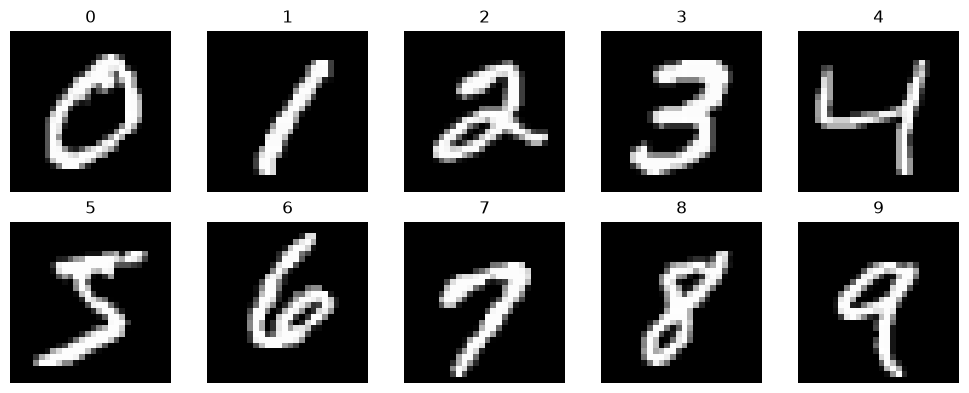

In [8]:
classes = [str(i) for i in range(10)]

examples = {}

for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()

    if len(examples) == 10:
        break

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Criação dos Dataloaders Reprodutíveis

Definimos uma função para criação dos dataloaders que nos permita retomar o treinamento em caso de interrupção forçada ou indesejada. Por isso retornamos o generator explicitamente, que será persistido junto com o checkpoint durante o treino.

In [9]:
def criar_train_dataloader(dataset, batch_size, seed, generator_state=None):
    generator = torch.Generator()

    if generator_state is None:
        generator.manual_seed(seed)
    else:
        generator.set_state(generator_state)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=generator
    )

    return dataloader, generator

Já para o conjunto de testes não é necessário mecanismo de retomada, pois o DataLoader não utilizar a função "Shuffle"

In [10]:
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

for X, y in test_dataloader:
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")
    print(f"Forma de y [N, ]: {y.shape}, Tipo de dados em y: {y.dtype}")
    break

Forma de X [N, C, H, W]: torch.Size([32, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ]: torch.Size([32]), Tipo de dados em y: torch.int64


## Criação de Vetores Latentes Fixos

In [11]:
diretorio_resultados = Path("resultados_lab2_dcgan")
diretorio_resultados.mkdir(parents=True, exist_ok=True)

arquivo_vetores_avaliacao = diretorio_resultados / "vetores_avaliacao.pt"


if arquivo_vetores_avaliacao.exists():

    msg_warning = "Verifique se houve modificação em z_dim entre a ultima execução e a atual."

    vetores_avaliacao = torch.load(
        arquivo_vetores_avaliacao,
        map_location="cpu"
    )

    if vetores_avaliacao["seed"] != seed:
        print(msg_warning)
        raise ValueError(
            f"Seed incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['seed']} != {seed}"
        )

    if vetores_avaliacao["z_dim"] != z_dim:
        print(msg_warning)
        raise ValueError(
            f"z_dim incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['z_dim']} != {z_dim}"
        )

    if vetores_avaliacao["n_amostras"] != n_amostras:
        print(msg_warning)
        raise ValueError(
            f"n_amostras incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['n_amostras']} != {n_amostras}"
        )

    z_evolucao = vetores_avaliacao["z_evolucao"]
    z_amostras = vetores_avaliacao["z_amostras"]
    z_interp_1 = vetores_avaliacao["z_interp_1"]
    z_interp_2 = vetores_avaliacao["z_interp_2"]


    if z_evolucao.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_evolucao.")

    if z_amostras.shape != (n_amostras, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_amostras.")

    if z_interp_1.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_interp_1.")

    if z_interp_2.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_interp_2.")

    print("Vetores latentes de avaliação recuperados.")

else:

    generator_avaliacao = torch.Generator(device="cpu")
    generator_avaliacao.manual_seed(seed)

    z_evolucao = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    z_amostras = torch.randn(
        (n_amostras, z_dim),
        generator=generator_avaliacao
    )

    z_interp_1 = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    z_interp_2 = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    torch.save(
        {
            "seed": seed,
            "z_dim": z_dim,
            "n_amostras": n_amostras,
            "z_evolucao": z_evolucao,
            "z_amostras": z_amostras,
            "z_interp_1": z_interp_1,
            "z_interp_2": z_interp_2
        },
        arquivo_vetores_avaliacao
    )

    print("Vetores latentes de avaliação criados e persistidos.")

Vetores latentes de avaliação recuperados.


## Redes Neurais

### Funções auxiliares de parametrização dos modelos

In [12]:
def parametros_transicao_gerador(resolucao_origem, resolucao_destino):
    fator = resolucao_destino // resolucao_origem

    if fator == 2:
        return {
            "kernel_size": 5,
            "stride": 2,
            "padding": 2,
            "output_padding": 1
        }

    if fator == 4:
        return {
            "kernel_size": 5,
            "stride": 4,
            "padding": 1,
            "output_padding": 1
        }

    raise ValueError(
        f"Transição não suportada no gerador: "
        f"{resolucao_origem} -> {resolucao_destino}"
    )


def parametros_transicao_discriminador(resolucao_origem, resolucao_destino):
    fator = resolucao_origem // resolucao_destino

    if fator == 2:
        return {
            "kernel_size": 5,
            "stride": 2,
            "padding": 2
        }

    if fator == 4:
        return {
            "kernel_size": 5,
            "stride": 4,
            "padding": 1
        }

    raise ValueError(
        f"Transição não suportada no discriminador: "
        f"{resolucao_origem} -> {resolucao_destino}"
    )

### Gerador

Definimos nosso gerador, parametrizado para suportar as variações que pretendemos estabelecer no experimento.

In [13]:
class Gerador(nn.Module):
    def __init__(
        self,
        z_dim=100,
        resolucoes=(7, 14, 28),
        canais=(128, 64),
        camadas_extras=(0, 0)
    ):
        super().__init__()

        if len(resolucoes) != len(canais) + 1:
            raise ValueError(
                "No gerador, 'resolucoes' deve possuir um elemento a mais que 'canais'."
            )

        if len(camadas_extras) != len(canais):
            raise ValueError(
                "'camadas_extras' deve possuir um valor para cada escala interna."
            )

        if resolucoes[0] != 7 or resolucoes[-1] != 28:
            raise ValueError("O gerador deve operar da resolução 7 para 28.")

        camadas = [
            nn.Linear(z_dim, 7 * 7 * canais[0]),
            nn.Unflatten(
                dim=1,
                unflattened_size=(canais[0], 7, 7)
            ),
            nn.BatchNorm2d(canais[0])
        ]

        # Camadas adicionais na resolução inicial
        for _ in range(camadas_extras[0]):
            camadas.extend([
                nn.Conv2d(
                    canais[0],
                    canais[0],
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
                nn.ReLU(True),
                nn.BatchNorm2d(canais[0])
            ])

        # Transições entre as escalas internas
        for i in range(len(canais) - 1):
            parametros = parametros_transicao_gerador(
                resolucoes[i],
                resolucoes[i + 1]
            )

            camadas.extend([
                nn.ConvTranspose2d(
                    canais[i],
                    canais[i + 1],
                    **parametros
                ),
                nn.ReLU(True),
                nn.BatchNorm2d(canais[i + 1])
            ])

            for _ in range(camadas_extras[i + 1]):
                camadas.extend([
                    nn.Conv2d(
                        canais[i + 1],
                        canais[i + 1],
                        kernel_size=3,
                        stride=1,
                        padding=1
                    ),
                    nn.ReLU(True),
                    nn.BatchNorm2d(canais[i + 1])
                ])

        # Última transição produz a imagem 28 x 28 com um canal
        parametros = parametros_transicao_gerador(
            resolucoes[-2],
            resolucoes[-1]
        )

        camadas.extend([
            nn.ConvTranspose2d(
                canais[-1],
                1,
                **parametros
            ),
            nn.Tanh()
        ])

        self.net = nn.Sequential(*camadas)

    def forward(self, z):
        return self.net(z)

### Discriminador

E a seguir fazemos o mesmo para o discriminador.

In [14]:
class Discriminador(nn.Module):
    def __init__(
        self,
        resolucoes=(28, 14, 7),
        canais=(64, 128),
        camadas_extras=(0, 0),
        dropout=0.4
    ):
        super().__init__()

        if len(resolucoes) != len(canais) + 1:
            raise ValueError(
                "No discriminador, 'resolucoes' deve possuir um elemento a mais que 'canais'."
            )

        if len(camadas_extras) != len(canais):
            raise ValueError(
                "'camadas_extras' deve possuir um valor para cada escala interna."
            )

        if resolucoes[0] != 28 or resolucoes[-1] != 7:
            raise ValueError("O discriminador deve operar da resolução 28 para 7.")

        camadas = []

        for i in range(len(canais)):
            canais_entrada = 1 if i == 0 else canais[i - 1]

            parametros = parametros_transicao_discriminador(
                resolucoes[i],
                resolucoes[i + 1]
            )

            camadas.extend([
                nn.Conv2d(
                    canais_entrada,
                    canais[i],
                    **parametros
                ),
                nn.LeakyReLU(negative_slope=0.2),
                nn.Dropout(p=dropout)
            ])

            for _ in range(camadas_extras[i]):
                camadas.extend([
                    nn.Conv2d(
                        canais[i],
                        canais[i],
                        kernel_size=3,
                        stride=1,
                        padding=1
                    ),
                    nn.LeakyReLU(negative_slope=0.2),
                    nn.Dropout(p=dropout)
                ])

        camadas.extend([
            nn.Flatten(),
            nn.Linear(
                resolucoes[-1] * resolucoes[-1] * canais[-1],
                1
            ),
            nn.Sigmoid()
        ])

        self.net = nn.Sequential(*camadas)

    def forward(self, x):
        return self.net(x)

### Definição da configuração base de referencia.

In [15]:
config_gerador_base = {
    "z_dim": z_dim,
    "resolucoes": [7, 14, 28],
    "canais": [128, 64],
    "camadas_extras": [0, 0]
}

config_discriminador_base = {
    "resolucoes": [28, 14, 7],
    "canais": [64, 128],
    "camadas_extras": [0, 0],
    "dropout": 0.4
}

### Criação e Exibição da Arquitetura Base de Referência

In [16]:
definir_semente(seed)

modelo_gerador_base = Gerador(**config_gerador_base)
modelo_discriminador_base = Discriminador(**config_discriminador_base)

z_teste = torch.randn((batch_size, z_dim))

with torch.no_grad():
    imagens_teste = modelo_gerador_base(z_teste)
    saidas_teste = modelo_discriminador_base(imagens_teste)

assert imagens_teste.shape == (batch_size, 1, 28, 28)
assert saidas_teste.shape == (batch_size, 1)

print(modelo_gerador_base)
print()
print(modelo_discriminador_base)

print()
print(f"Parâmetros do gerador: {contar_parametros(modelo_gerador_base):,}")
print(f"Parâmetros do discriminador: {contar_parametros(modelo_discriminador_base):,}")
print(f"Saída do gerador: {imagens_teste.shape}")
print(f"Saída do discriminador: {saidas_teste.shape}")

Gerador(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)

Discriminador(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
 

### Validação da Arquitetura Base

In [17]:
def validar_arquitetura_base(gerador, discriminador):
    # Gerador
    assert isinstance(gerador.net[0], nn.Linear)
    assert gerador.net[0].in_features == 100
    assert gerador.net[0].out_features == 7 * 7 * 128

    assert isinstance(gerador.net[1], nn.Unflatten)
    assert isinstance(gerador.net[2], nn.BatchNorm2d)
    assert gerador.net[2].num_features == 128

    assert isinstance(gerador.net[3], nn.ConvTranspose2d)
    assert gerador.net[3].in_channels == 128
    assert gerador.net[3].out_channels == 64
    assert gerador.net[3].kernel_size == (5, 5)
    assert gerador.net[3].stride == (2, 2)
    assert gerador.net[3].padding == (2, 2)
    assert gerador.net[3].output_padding == (1, 1)

    assert isinstance(gerador.net[4], nn.ReLU)

    assert isinstance(gerador.net[5], nn.BatchNorm2d)
    assert gerador.net[5].num_features == 64

    assert isinstance(gerador.net[6], nn.ConvTranspose2d)
    assert gerador.net[6].in_channels == 64
    assert gerador.net[6].out_channels == 1
    assert gerador.net[6].kernel_size == (5, 5)
    assert gerador.net[6].stride == (2, 2)
    assert gerador.net[6].padding == (2, 2)
    assert gerador.net[6].output_padding == (1, 1)

    assert isinstance(gerador.net[7], nn.Tanh)

    # Discriminador
    assert isinstance(discriminador.net[0], nn.Conv2d)
    assert discriminador.net[0].in_channels == 1
    assert discriminador.net[0].out_channels == 64
    assert discriminador.net[0].kernel_size == (5, 5)
    assert discriminador.net[0].stride == (2, 2)
    assert discriminador.net[0].padding == (2, 2)

    assert isinstance(discriminador.net[1], nn.LeakyReLU)
    assert discriminador.net[1].negative_slope == 0.2

    assert isinstance(discriminador.net[2], nn.Dropout)
    assert discriminador.net[2].p == 0.4

    assert isinstance(discriminador.net[3], nn.Conv2d)
    assert discriminador.net[3].in_channels == 64
    assert discriminador.net[3].out_channels == 128
    assert discriminador.net[3].kernel_size == (5, 5)
    assert discriminador.net[3].stride == (2, 2)
    assert discriminador.net[3].padding == (2, 2)

    assert isinstance(discriminador.net[4], nn.LeakyReLU)
    assert discriminador.net[4].negative_slope == 0.2

    assert isinstance(discriminador.net[5], nn.Dropout)
    assert discriminador.net[5].p == 0.4

    assert isinstance(discriminador.net[6], nn.Flatten)

    assert isinstance(discriminador.net[7], nn.Linear)
    assert discriminador.net[7].in_features == 7 * 7 * 128
    assert discriminador.net[7].out_features == 1

    assert isinstance(discriminador.net[8], nn.Sigmoid)

    # Quantidade total de parâmetros
    assert contar_parametros(gerador) == 840_321
    assert contar_parametros(discriminador) == 212_865

    # Formato das saídas
    z_teste = torch.randn((batch_size, z_dim))

    with torch.no_grad():
        imagens_teste = gerador(z_teste)
        saidas_teste = discriminador(imagens_teste)

    assert imagens_teste.shape == (batch_size, 1, 28, 28)
    assert saidas_teste.shape == (batch_size, 1)

    print("Arquitetura base validada com sucesso.")


validar_arquitetura_base(
    modelo_gerador_base,
    modelo_discriminador_base
)

Arquitetura base validada com sucesso.


## Configurações dos Experimentos

### Definição declarativa

In [18]:
experimentos = {

    # ============================================================
    # Configuração base
    # ============================================================

    "base": {
        "nome": "Base",
        "fator": "referencia",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Capacidade do gerador
    # ============================================================

    "gerador_reduzido": {
        "nome": "Gerador reduzido",
        "fator": "capacidade_gerador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 28],
            "canais": [32],
            "camadas_extras": [0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    "gerador_ampliado": {
        "nome": "Gerador ampliado",
        "fator": "capacidade_gerador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [256, 128],
            "camadas_extras": [2, 2]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Capacidade do discriminador
    # ============================================================

    "discriminador_reduzido": {
        "nome": "Discriminador reduzido",
        "fator": "capacidade_discriminador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [24, 64],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    "discriminador_ampliado": {
        "nome": "Discriminador ampliado",
        "fator": "capacidade_discriminador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [80, 160],
            "camadas_extras": [2, 2],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Gerador e Discriminador ampliados
    # ============================================================

    "ambos_ampliados": {
        "nome": "Gerador e discriminador ampliados",
        "fator": "capacidade_ambos",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [256, 128],
            "camadas_extras": [2, 2]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [80, 160],
            "camadas_extras": [2, 2],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Taxas de aprendizado
    # ============================================================

    "lr_gerador_maior": {
        "nome": "LR gerador >> discriminador",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-5
        }
    },

    "lr_discriminador_maior": {
        "nome": "LR gerador << discriminador",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-5,
            "lr_discriminador": 1e-3
        }
    },

    "lr_ambos_menores": {
        "nome": "LR ambos menores",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-4,
            "lr_discriminador": 1e-4
        }
    },

    # ============================================================
    # Otimizador
    # ============================================================

    "sgd": {
        "nome": "SGD",
        "fator": "otimizador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "SGD",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    }
}

### Validação da Definição

In [19]:
def validar_experimentos(experimentos):
    base = experimentos["base"]

    for id_experimento, config in experimentos.items():

        assert config["gerador"]["z_dim"] == z_dim
        assert config["treinamento"]["batch_size"] == batch_size
        assert config["treinamento"]["num_epochs"] == num_epochs
        assert config["treinamento"]["seed"] == seed
        assert config["treinamento"]["loss_fn"] == "BCELoss"

        fator = config["fator"]

        if fator == "capacidade_gerador":
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"] == base["treinamento"]

        elif fator == "capacidade_discriminador":
            assert config["gerador"] == base["gerador"]
            assert config["treinamento"] == base["treinamento"]

        elif fator == "learning_rate":
            assert config["gerador"] == base["gerador"]
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"]["otimizador"] == "RMSprop"

        elif fator == "otimizador":
            assert config["gerador"] == base["gerador"]
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"]["lr_gerador"] == base["treinamento"]["lr_gerador"]
            assert config["treinamento"]["lr_discriminador"] == base["treinamento"]["lr_discriminador"]

        elif fator == "capacidade_ambos":
            assert config["gerador"] == experimentos["gerador_ampliado"]["gerador"]
            assert config["discriminador"] == experimentos["discriminador_ampliado"]["discriminador"]
            assert config["treinamento"] == base["treinamento"]

    print(f"{len(experimentos)} configurações de experimento validadas.")


validar_experimentos(experimentos)

10 configurações de experimento validadas.


### Exibir Tabela de Experimentos

In [20]:
def resumir_arquitetura(config, tipo):
    resolucoes = " → ".join(map(str, config["resolucoes"]))
    canais = " → ".join(map(str, config["canais"]))
    extras = " → ".join(map(str, config["camadas_extras"]))

    return (
        f"res={resolucoes}; "
        f"canais={canais}; "
        f"extras={extras}"
    )


def criar_tabela_experimentos(experimentos):
    linhas = []

    for id_experimento, config in experimentos.items():
        gerador = Gerador(**config["gerador"])
        discriminador = Discriminador(**config["discriminador"])

        treinamento = config["treinamento"]

        linhas.append({
            "Experimento": id_experimento,
            "Nome": config["nome"],
            "Fator": config["fator"],
            "Gerador": resumir_arquitetura(
                config["gerador"],
                "gerador"
            ),
            "Parâmetros G": contar_parametros(gerador),
            "Discriminador": resumir_arquitetura(
                config["discriminador"],
                "discriminador"
            ),
            "Parâmetros D": contar_parametros(discriminador),
            "Otimizador": treinamento["otimizador"],
            "LR G": treinamento["lr_gerador"],
            "LR D": treinamento["lr_discriminador"]
        })

    return pd.DataFrame(linhas)


tabela_experimentos = criar_tabela_experimentos(experimentos)

tabela_experimentos

,Experimento,Nome,Fator,Gerador,Parâmetros G,Discriminador,Parâmetros D,Otimizador,LR G,LR D
0,base,Base,referencia,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
1,gerador_reduzido,Gerador reduzido,capacidade_gerador,res=7 → 28; canais=32; extras=0,159233,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
2,gerador_ampliado,Gerador ampliado,capacidade_gerador,res=7 → 14 → 28; canais=256 → 128; extras=2 → 2,3567105,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
3,discriminador_reduzido,Discriminador reduzido,capacidade_discriminador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=24 → 64; extras=0 → 0,42225,RMSprop,0.00100,0.00100
4,discriminador_ampliado,Discriminador ampliado,capacidade_discriminador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=80 → 160; extras=2 → 2,906561,RMSprop,0.00100,0.00100
5,ambos_ampliados,Gerador e discriminador ampliados,capacidade_ambos,res=7 → 14 → 28; canais=256 → 128; extras=2 → 2,3567105,res=28 → 14 → 7; canais=80 → 160; extras=2 → 2,906561,RMSprop,0.00100,0.00100
6,lr_gerador_maior,LR gerador >> discriminador,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00001
7,lr_discriminador_maior,LR gerador << discriminador,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00001,0.00100
8,lr_ambos_menores,LR ambos menores,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00010,0.00010
9,sgd,SGD,otimizador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,SGD,0.00100,0.00100


### Critério de Redução e Amplicação de Capacidades do Modelo

A capacidade dos modelos foi comparada principalmente pelo número de parâmetros treináveis. As versões reduzidas foram ajustadas para manter cerca de 20% da capacidade da configuração base, enquanto as ampliadas ficaram em torno de 4,25 vezes o número original de parâmetros. A tabela a seguir mostra isso em detalhes.

In [21]:
comparacao_capacidade = pd.DataFrame([
    {
        "Rede": "Gerador",
        "Base": contar_parametros(
            Gerador(**experimentos["base"]["gerador"])
        ),
        "Reduzida": contar_parametros(
            Gerador(**experimentos["gerador_reduzido"]["gerador"])
        ),
        "Ampliada": contar_parametros(
            Gerador(**experimentos["gerador_ampliado"]["gerador"])
        )
    },
    {
        "Rede": "Discriminador",
        "Base": contar_parametros(
            Discriminador(**experimentos["base"]["discriminador"])
        ),
        "Reduzida": contar_parametros(
            Discriminador(**experimentos["discriminador_reduzido"]["discriminador"])
        ),
        "Ampliada": contar_parametros(
            Discriminador(**experimentos["discriminador_ampliado"]["discriminador"])
        )
    }
])

comparacao_capacidade["Redução (%)"] = (
    1 - comparacao_capacidade["Reduzida"] / comparacao_capacidade["Base"]
) * 100

comparacao_capacidade["Ampliação (x)"] = (
    comparacao_capacidade["Ampliada"] / comparacao_capacidade["Base"]
)

comparacao_capacidade

,Rede,Base,Reduzida,Ampliada,Redução (%),Ampliação (x)
0,Gerador,840321,159233,3567105,81.050932,4.244931
1,Discriminador,212865,42225,906561,80.163484,4.258854


## Treinamento

### Criação de Funções de Perda e de Otimizadores

In [22]:
def criar_loss_fn(config_treinamento):
    nome = config_treinamento["loss_fn"]

    if nome == "BCELoss":
        return nn.BCELoss()

    raise ValueError(f"Função de perda não suportada: {nome}")

In [23]:
def criar_otimizadores(
    gerador,
    discriminador,
    config_treinamento
):
    nome = config_treinamento["otimizador"]

    lr_gerador = config_treinamento["lr_gerador"]
    lr_discriminador = config_treinamento["lr_discriminador"]

    if nome == "RMSprop":
        opt_gerador = torch.optim.RMSprop(
            gerador.parameters(),
            lr=lr_gerador
        )

        opt_discriminador = torch.optim.RMSprop(
            discriminador.parameters(),
            lr=lr_discriminador
        )

    elif nome == "SGD":
        opt_gerador = torch.optim.SGD(
            gerador.parameters(),
            lr=lr_gerador
        )

        opt_discriminador = torch.optim.SGD(
            discriminador.parameters(),
            lr=lr_discriminador
        )

    else:
        raise ValueError(f"Otimizador não suportado: {nome}")

    return opt_gerador, opt_discriminador

#### Validação da Configuração Base

In [24]:
config_treinamento_base = experimentos["base"]["treinamento"]

loss_fn_teste = criar_loss_fn(
    config_treinamento_base
)

opt_gerador_teste, opt_discriminador_teste = criar_otimizadores(
    modelo_gerador_base,
    modelo_discriminador_base,
    config_treinamento_base
)

assert isinstance(loss_fn_teste, nn.BCELoss)

assert isinstance(
    opt_gerador_teste,
    torch.optim.RMSprop
)

assert isinstance(
    opt_discriminador_teste,
    torch.optim.RMSprop
)

assert opt_gerador_teste.param_groups[0]["lr"] == 1e-3
assert opt_discriminador_teste.param_groups[0]["lr"] == 1e-3

print("Função de perda e otimizadores da configuração base validados.")

Função de perda e otimizadores da configuração base validados.


### Função de Treinamento

In [25]:
def train_dcgan(
    dataloader,
    gerador,
    discriminador,
    loss_fn,
    opt_gerador,
    opt_discriminador,
    device,
    epoch,
    z_dim
):
    gerador.train()
    discriminador.train()

    soma_perda_gerador = torch.zeros((), device=device)
    soma_perda_discriminador = torch.zeros((), device=device)
    soma_score_reais = torch.zeros((), device=device)
    soma_score_falsos = torch.zeros((), device=device)

    num_lotes = len(dataloader)

    for batch, (real_data, _) in enumerate(dataloader):

        batch_atual = real_data.shape[0]
        real_data = real_data.to(device)

        # ========================================================
        # Treinamento do discriminador
        # ========================================================

        labels_reais = torch.ones(
            (batch_atual, 1),
            device=device
        )

        labels_falsos = torch.zeros(
            (batch_atual, 1),
            device=device
        )

        z = torch.randn(
            (batch_atual, z_dim),
            device=device
        )

        dados_falsos = gerador(z)

        saida_reais = discriminador(real_data)
        saida_falsos_d = discriminador(
            dados_falsos.detach()
        )

        perda_reais = loss_fn(
            saida_reais,
            labels_reais
        )

        perda_falsos = loss_fn(
            saida_falsos_d,
            labels_falsos
        )

        perda_discriminador = (
            perda_reais + perda_falsos
        )

        opt_discriminador.zero_grad()
        perda_discriminador.backward()
        opt_discriminador.step()

        # ========================================================
        # Treinamento do gerador
        # ========================================================

        z = torch.randn(
            (batch_atual, z_dim),
            device=device
        )

        dados_falsos = gerador(z)

        saida_falsos_g = discriminador(
            dados_falsos
        )

        perda_gerador = loss_fn(
            saida_falsos_g,
            labels_reais
        )

        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # ========================================================
        # Acumulação das métricas da época
        # ========================================================

        soma_perda_gerador += perda_gerador.detach()
        soma_perda_discriminador += perda_discriminador.detach()

        soma_score_reais += saida_reais.detach().mean()
        soma_score_falsos += saida_falsos_d.detach().mean()

        # ========================================================
        # Log de progresso
        # ========================================================

        if batch % 100 == 0 or batch == num_lotes - 1:
            print(
                f"[Época {epoch:03d}] "
                f"[Lote {batch:04d}/{num_lotes - 1:04d}] "
                f"Perda D: {perda_discriminador.item():.4f} | "
                f"Perda G: {perda_gerador.item():.4f} | "
                f"Score reais: {saida_reais.detach().mean().item():.4f} | "
                f"Score falsos: {saida_falsos_d.detach().mean().item():.4f}"
            )

    return {
        "loss_gerador":       (soma_perda_gerador       / num_lotes).item(),
        "loss_discriminador": (soma_perda_discriminador / num_lotes).item(),
        "score_reais":        (soma_score_reais         / num_lotes).item(),
        "score_falsos":       (soma_score_falsos        / num_lotes).item()
    }

## Funções Auxiliares de Avaliação

### Geração de imagens a partir de vetores latentes

In [26]:
def gerar_saida(
    gerador,
    z,
    device
):
    gerador.eval()

    with torch.no_grad():
        imagens = gerador(
            z.to(device)
        ).detach().cpu()

    return imagens

### Geração da saída para acompanhamento da evolução do treinamento

In [27]:
def gerar_evolucao(
    gerador,
    z_evolucao,
    device
):
    imagens = gerar_saida(
        gerador=gerador,
        z=z_evolucao,
        device=device
    )

    return imagens.squeeze(0)

### Geração das amostras finais do experimento

In [28]:
def gerar_amostras_finais(
    gerador,
    z_amostras,
    device
):
    return gerar_saida(
        gerador=gerador,
        z=z_amostras,
        device=device
    )

### Validação das funções

In [29]:
modelo_gerador_base.to(device)

imagem_evolucao_teste = gerar_evolucao(
    gerador=modelo_gerador_base,
    z_evolucao=z_evolucao,
    device=device
)

amostras_teste = gerar_amostras_finais(
    gerador=modelo_gerador_base,
    z_amostras=z_amostras,
    device=device
)

assert imagem_evolucao_teste.device.type == "cpu"
assert amostras_teste.device.type == "cpu"

assert imagem_evolucao_teste.shape == (1, 28, 28)
assert amostras_teste.shape == (n_amostras, 1, 28, 28)

print("Funções de geração para avaliação validadas.")

Funções de geração para avaliação validadas.


## Salvamento e Recuperação

### Caminhos e salvamento seguro dos arquivos

In [30]:
def obter_caminhos_experimento(id_experimento):
    diretorio = diretorio_resultados / id_experimento
    diretorio.mkdir(parents=True, exist_ok=True)

    return {
        "diretorio": diretorio,
        "checkpoint_treinamento": diretorio / "checkpoint_treinamento.pt",
        "checkpoint_final": diretorio / "checkpoint_final.pt",
        "resultado": diretorio / "resultado.pt"
    }


def mover_para_cpu(objeto):
    if isinstance(objeto, torch.Tensor):
        return objeto.detach().cpu()

    if isinstance(objeto, dict):
        return {
            chave: mover_para_cpu(valor)
            for chave, valor in objeto.items()
        }

    if isinstance(objeto, list):
        return [
            mover_para_cpu(valor)
            for valor in objeto
        ]

    if isinstance(objeto, tuple):
        return tuple(
            mover_para_cpu(valor)
            for valor in objeto
        )

    return objeto


def salvar_torch_atomico(objeto, caminho):
    caminho_temporario = caminho.with_suffix(
        caminho.suffix + ".tmp"
    )

    torch.save(
        mover_para_cpu(objeto),
        caminho_temporario
    )

    caminho_temporario.replace(caminho)

### Captura e restauração dos estados aleatórios

In [31]:
def capturar_estado_rng(device):
    estado = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "device_type": device.type
    }

    if device.type == "cuda":
        estado["torch_device"] = torch.cuda.get_rng_state_all()

    elif device.type == "mps":
        estado["torch_device"] = torch.mps.get_rng_state()

    return mover_para_cpu(estado)


def restaurar_estado_rng(estado, device):
    if estado["device_type"] != device.type:
        raise ValueError(
            f"O checkpoint foi criado em '{estado['device_type']}', "
            f"mas a retomada está sendo executada em '{device.type}'."
        )

    random.setstate(estado["python"])
    np.random.set_state(estado["numpy"])
    torch.set_rng_state(estado["torch_cpu"])

    if device.type == "cuda":
        torch.cuda.set_rng_state_all(
            estado["torch_device"]
        )

    elif device.type == "mps":
        torch.mps.set_rng_state(
            estado["torch_device"]
        )

### Salvamento do checkpoint de treinamento

In [32]:
def salvar_checkpoint_treinamento(
    id_experimento,
    config,
    epoch,
    gerador,
    discriminador,
    opt_gerador,
    opt_discriminador,
    historico,
    evolucao_z_fixo,
    dataloader_generator,
    device
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    checkpoint = {
        "id_experimento": id_experimento,
        "config": config,
        "epoch": epoch,

        "gerador_state_dict": gerador.state_dict(),
        "discriminador_state_dict": discriminador.state_dict(),

        "opt_gerador_state_dict": opt_gerador.state_dict(),
        "opt_discriminador_state_dict": opt_discriminador.state_dict(),

        "historico": historico,
        "evolucao_z_fixo": evolucao_z_fixo,

        "dataloader_generator_state":
            dataloader_generator.get_state(),

        "rng_state": capturar_estado_rng(device)
    }

    salvar_torch_atomico(
        checkpoint,
        caminhos["checkpoint_treinamento"]
    )

### Recuperação do checkpoint de treinamento

In [33]:
def carregar_checkpoint_treinamento(
    id_experimento,
    config
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    caminho = caminhos["checkpoint_treinamento"]

    if not caminho.exists():
        return None

    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    if checkpoint["id_experimento"] != id_experimento:
        raise ValueError(
            "O checkpoint pertence a outro experimento."
        )

    if checkpoint["config"] != config:
        raise ValueError(
            f"A configuração atual do experimento "
            f"'{id_experimento}' é diferente da configuração "
            f"armazenada no checkpoint."
        )

    validar_historico(
        historico=checkpoint["historico"],
        epocas_concluidas=checkpoint["epoch"],
        evolucao_z_fixo=checkpoint["evolucao_z_fixo"]
    )

    return checkpoint

### Salvamento do checkpoint e do resultado final

In [34]:
def salvar_resultado_final(
    id_experimento,
    config,
    gerador,
    discriminador,
    historico,
    evolucao_z_fixo,
    amostras_finais,
    device
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    checkpoint_final = {
        "id_experimento": id_experimento,
        "config": config,

        "gerador_state_dict": gerador.state_dict(),
        "discriminador_state_dict": discriminador.state_dict()
    }

    resultado = {
        "id_experimento": id_experimento,
        "config": config,

        "historico": historico,

        "avaliacao": {
            "evolucao_z_fixo": torch.stack(
                evolucao_z_fixo
            ),
            "amostras_finais": amostras_finais
        },

        "metadados": {
            "seed": config["treinamento"]["seed"],
            "num_epochs": config["treinamento"]["num_epochs"],
            "batch_size": config["treinamento"]["batch_size"],
            "z_dim": config["gerador"]["z_dim"],
            "device_treinamento": device.type,
            "parametros_gerador": contar_parametros(gerador),
            "parametros_discriminador": contar_parametros(discriminador)
        }
    }

    salvar_torch_atomico(
        checkpoint_final,
        caminhos["checkpoint_final"]
    )

    salvar_torch_atomico(
        resultado,
        caminhos["resultado"]
    )

    if caminhos["checkpoint_treinamento"].exists():
        caminhos["checkpoint_treinamento"].unlink()

### Carregamento de resultados já concluídos

In [35]:
def carregar_resultado_final(
    id_experimento,
    config
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    caminho = caminhos["resultado"]

    if not caminho.exists():
        return None

    resultado = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    if resultado["id_experimento"] != id_experimento:
        raise ValueError(
            "O resultado pertence a outro experimento."
        )

    if resultado["config"] != config:
        raise ValueError(
            f"A configuração atual do experimento "
            f"'{id_experimento}' é diferente da configuração "
            f"armazenada no resultado."
        )

    return resultado

## Execução dos Experimentos

### Estrutura de controle de execução do experimentos

A seguir definimos funções auxiliares que ajudam na estruturação do controle de execução dos experimentos. Cada função realiza uma tarefa bem definida, e no final uma função principal consolida cada uma das etapas.

#### Validação estrutural do resultado

In [36]:
def validar_resultado_experimento(
    resultado,
    config
):
    num_epochs_esperado = config["treinamento"]["num_epochs"]

    historico = resultado["historico"]
    avaliacao = resultado["avaliacao"]

    validar_historico(
        historico=historico,
        epocas_concluidas=num_epochs_esperado,
        evolucao_z_fixo=avaliacao["evolucao_z_fixo"]
    )

    assert avaliacao["evolucao_z_fixo"].shape == (
        num_epochs_esperado + 1,
        1,
        28,
        28
    )

    assert avaliacao["amostras_finais"].shape == (
        n_amostras,
        1,
        28,
        28
    )

    assert avaliacao["evolucao_z_fixo"].device.type == "cpu"
    assert avaliacao["amostras_finais"].device.type == "cpu"

    print("Estrutura do resultado validada com sucesso.")

#### Validação da consistência do histórico

In [37]:
def validar_historico(
    historico,
    epocas_concluidas,
    evolucao_z_fixo
):
    chaves = [
        "loss_gerador",
        "loss_discriminador",
        "score_reais",
        "score_falsos"
    ]

    for chave in chaves:
        assert len(historico[chave]) == epocas_concluidas, (
            f"Histórico '{chave}' inconsistente: "
            f"{len(historico[chave])} registros para "
            f"{epocas_concluidas} épocas concluídas."
        )

        assert np.all(np.isfinite(historico[chave])), (
            f"Histórico '{chave}' contém valores NaN ou infinitos."
        )

    assert len(evolucao_z_fixo) == epocas_concluidas + 1, (
        f"Evolução do vetor fixo inconsistente: "
        f"{len(evolucao_z_fixo)} registros para "
        f"{epocas_concluidas} épocas concluídas."
    )

#### Inicialização de um novo experimento

In [38]:
def iniciar_novo_experimento(
    config,
    training_data,
    device,
    z_evolucao
):
    config_treinamento = config["treinamento"]

    definir_semente(
        config_treinamento["seed"]
    )

    gerador = Gerador(
        **config["gerador"]
    ).to(device)

    discriminador = Discriminador(
        **config["discriminador"]
    ).to(device)

    loss_fn = criar_loss_fn(
        config_treinamento
    )

    opt_gerador, opt_discriminador = criar_otimizadores(
        gerador,
        discriminador,
        config_treinamento
    )

    train_dataloader, dataloader_generator = criar_train_dataloader(
        dataset=training_data,
        batch_size=config_treinamento["batch_size"],
        seed=config_treinamento["seed"]
    )

    historico = {
        "loss_gerador": [],
        "loss_discriminador": [],
        "score_reais": [],
        "score_falsos": []
    }

    # Época 0: saída antes do treinamento
    evolucao_z_fixo = [
        gerar_evolucao(
            gerador=gerador,
            z_evolucao=z_evolucao,
            device=device
        )
    ]

    return {
        "gerador": gerador,
        "discriminador": discriminador,
        "loss_fn": loss_fn,
        "opt_gerador": opt_gerador,
        "opt_discriminador": opt_discriminador,
        "train_dataloader": train_dataloader,
        "dataloader_generator": dataloader_generator,
        "historico": historico,
        "evolucao_z_fixo": evolucao_z_fixo,
        "epoca_inicial": 1
    }

#### Retomada de um experimento interrompido

In [39]:
def retomar_experimento(
    config,
    checkpoint,
    training_data,
    device
):
    config_treinamento = config["treinamento"]

    gerador = Gerador(
        **config["gerador"]
    ).to(device)

    discriminador = Discriminador(
        **config["discriminador"]
    ).to(device)

    gerador.load_state_dict(
        checkpoint["gerador_state_dict"]
    )

    discriminador.load_state_dict(
        checkpoint["discriminador_state_dict"]
    )

    loss_fn = criar_loss_fn(
        config_treinamento
    )

    opt_gerador, opt_discriminador = criar_otimizadores(
        gerador,
        discriminador,
        config_treinamento
    )

    opt_gerador.load_state_dict(
        checkpoint["opt_gerador_state_dict"]
    )

    opt_discriminador.load_state_dict(
        checkpoint["opt_discriminador_state_dict"]
    )

    train_dataloader, dataloader_generator = criar_train_dataloader(
        dataset=training_data,
        batch_size=config_treinamento["batch_size"],
        seed=config_treinamento["seed"],
        generator_state=checkpoint[
            "dataloader_generator_state"
        ]
    )

    restaurar_estado_rng(
        checkpoint["rng_state"],
        device
    )

    return {
        "gerador": gerador,
        "discriminador": discriminador,
        "loss_fn": loss_fn,
        "opt_gerador": opt_gerador,
        "opt_discriminador": opt_discriminador,
        "train_dataloader": train_dataloader,
        "dataloader_generator": dataloader_generator,
        "historico": checkpoint["historico"],
        "evolucao_z_fixo": checkpoint["evolucao_z_fixo"],
        "epoca_inicial": checkpoint["epoch"] + 1
    }

#### Registro das métricas de uma época

In [40]:
def registrar_metricas_epoca(
    historico,
    metricas
):
    historico["loss_gerador"].append(
        metricas["loss_gerador"]
    )

    historico["loss_discriminador"].append(
        metricas["loss_discriminador"]
    )

    historico["score_reais"].append(
        metricas["score_reais"]
    )

    historico["score_falsos"].append(
        metricas["score_falsos"]
    )

#### Execução das épocas do experimento

In [41]:
def treinar_experimento(
    id_experimento,
    config,
    estado,
    device,
    z_evolucao
):
    num_epochs = config["treinamento"]["num_epochs"]
    z_dim = config["gerador"]["z_dim"]

    for epoch in range(
        estado["epoca_inicial"],
        num_epochs + 1
    ):
        metricas = train_dcgan(
            dataloader=estado["train_dataloader"],
            gerador=estado["gerador"],
            discriminador=estado["discriminador"],
            loss_fn=estado["loss_fn"],
            opt_gerador=estado["opt_gerador"],
            opt_discriminador=estado["opt_discriminador"],
            device=device,
            epoch=epoch,
            z_dim=z_dim
        )

        registrar_metricas_epoca(
            estado["historico"],
            metricas
        )

        estado["evolucao_z_fixo"].append(
            gerar_evolucao(
                gerador=estado["gerador"],
                z_evolucao=z_evolucao,
                device=device
            )
        )

        print(
            f"[Época {epoch:03d}] "
            f"Média D: {metricas['loss_discriminador']:.4f} | "
            f"Média G: {metricas['loss_gerador']:.4f} | "
            f"Score reais: {metricas['score_reais']:.4f} | "
            f"Score falsos: {metricas['score_falsos']:.4f}"
        )

        salvar_checkpoint_treinamento(
            id_experimento=id_experimento,
            config=config,
            epoch=epoch,
            gerador=estado["gerador"],
            discriminador=estado["discriminador"],
            opt_gerador=estado["opt_gerador"],
            opt_discriminador=estado["opt_discriminador"],
            historico=estado["historico"],
            evolucao_z_fixo=estado["evolucao_z_fixo"],
            dataloader_generator=estado["dataloader_generator"],
            device=device
        )

    return estado

#### Finalização e persistência do experimento

In [42]:
def finalizar_experimento(
    id_experimento,
    config,
    estado,
    device,
    z_amostras
):
    amostras_finais = gerar_amostras_finais(
        gerador=estado["gerador"],
        z_amostras=z_amostras,
        device=device
    )

    salvar_resultado_final(
        id_experimento=id_experimento,
        config=config,
        gerador=estado["gerador"],
        discriminador=estado["discriminador"],
        historico=estado["historico"],
        evolucao_z_fixo=estado["evolucao_z_fixo"],
        amostras_finais=amostras_finais,
        device=device
    )

    resultado = carregar_resultado_final(
        id_experimento,
        config
    )

    validar_resultado_experimento(
        resultado,
        config
    )

    return resultado

#### Execução completa de um experimento

In [43]:
def executar_experimento(
    id_experimento,
    config,
    training_data,
    device,
    z_evolucao,
    z_amostras
):
    # Recupera diretamente um experimento já concluído
    resultado = carregar_resultado_final( id_experimento, config )

    if resultado is not None:
        validar_resultado_experimento( resultado, config )

        print(
            f"[{id_experimento}] "
            f"Experimento já concluído. Resultado recuperado."
        )

        return resultado

    # Verifica se existe um checkpoint intermediário
    checkpoint = carregar_checkpoint_treinamento(
        id_experimento,
        config
    )

    if checkpoint is None:
        print(
            f"[{id_experimento}] "
            f"Iniciando novo treinamento."
        )

        estado = iniciar_novo_experimento(
            config=config,
            training_data=training_data,
            device=device,
            z_evolucao=z_evolucao
        )

    else:
        print(
            f"[{id_experimento}] "
            f"Retomando treinamento após a época "
            f"{checkpoint['epoch']}."
        )

        estado = retomar_experimento(
            config=config,
            checkpoint=checkpoint,
            training_data=training_data,
            device=device
        )

    print(
        f"Gerador: "
        f"{contar_parametros(estado['gerador']):,} parâmetros | "
        f"Discriminador: "
        f"{contar_parametros(estado['discriminador']):,} parâmetros"
    )

    print(
        f"Otimizador: {config['treinamento']['otimizador']} | "
        f"LR G: {config['treinamento']['lr_gerador']:.5f} | "
        f"LR D: {config['treinamento']['lr_discriminador']:.5f}"
    )

    estado = treinar_experimento(
        id_experimento=id_experimento,
        config=config,
        estado=estado,
        device=device,
        z_evolucao=z_evolucao
    )

    resultado = finalizar_experimento(
        id_experimento=id_experimento,
        config=config,
        estado=estado,
        device=device,
        z_amostras=z_amostras
    )

    print(
        f"[{id_experimento}] "
        f"Treinamento concluído e resultado persistido."
    )

    return resultado

#### Validação do controle do experimento

Executamos apenas o caso base, assim validaremos que o controle do experimentos, salvamento e recuperação estão funcionando perfeitamente. 

In [44]:
resultado_base = executar_experimento(
    id_experimento="base",
    config=experimentos["base"],
    training_data=training_data,
    device=device,
    z_evolucao=z_evolucao,
    z_amostras=z_amostras
)

[base] Iniciando novo treinamento.
Gerador: 840,321 parâmetros | Discriminador: 212,865 parâmetros
Otimizador: RMSprop | LR G: 0.00100 | LR D: 0.00100
[Época 001] [Lote 0000/1874] Perda D: 1.3375 | Perda G: 5.7067 | Score reais: 0.5198 | Score falsos: 0.4937
[Época 001] [Lote 0100/1874] Perda D: 1.2608 | Perda G: 1.7608 | Score reais: 0.7568 | Score falsos: 0.5843
[Época 001] [Lote 0200/1874] Perda D: 1.1191 | Perda G: 2.1067 | Score reais: 0.8286 | Score falsos: 0.5802
[Época 001] [Lote 0300/1874] Perda D: 1.0243 | Perda G: 2.4750 | Score reais: 0.8488 | Score falsos: 0.5458
[Época 001] [Lote 0400/1874] Perda D: 0.9808 | Perda G: 1.6082 | Score reais: 0.6594 | Score falsos: 0.3178
[Época 001] [Lote 0500/1874] Perda D: 0.9714 | Perda G: 2.3148 | Score reais: 0.8983 | Score falsos: 0.4716
[Época 001] [Lote 0600/1874] Perda D: 1.2680 | Perda G: 2.0279 | Score reais: 0.8166 | Score falsos: 0.5417
[Época 001] [Lote 0700/1874] Perda D: 0.9617 | Perda G: 1.3395 | Score reais: 0.6418 | Score 

### Execução de todos os experimentos

In [45]:
resultados = {}

for id_experimento, config in experimentos.items():

    print()
    print("=" * 80)
    print(f"Experimento: {config['nome']} ({id_experimento})")
    print("=" * 80)

    resultados[id_experimento] = executar_experimento(
        id_experimento=id_experimento,
        config=config,
        training_data=training_data,
        device=device,
        z_evolucao=z_evolucao,
        z_amostras=z_amostras
    )

print()
print(f"{len(resultados)} experimentos concluídos ou recuperados.")


Experimento: Base (base)
Estrutura do resultado validada com sucesso.
[base] Experimento já concluído. Resultado recuperado.

Experimento: Gerador reduzido (gerador_reduzido)
[gerador_reduzido] Iniciando novo treinamento.
Gerador: 159,233 parâmetros | Discriminador: 212,865 parâmetros
Otimizador: RMSprop | LR G: 0.00100 | LR D: 0.00100
[Época 001] [Lote 0000/1874] Perda D: 1.3844 | Perda G: 2.1188 | Score reais: 0.4879 | Score falsos: 0.4852
[Época 001] [Lote 0100/1874] Perda D: 0.3587 | Perda G: 4.7789 | Score reais: 0.9354 | Score falsos: 0.1888
[Época 001] [Lote 0200/1874] Perda D: 0.4728 | Perda G: 1.5565 | Score reais: 0.7538 | Score falsos: 0.1366
[Época 001] [Lote 0300/1874] Perda D: 1.0975 | Perda G: 0.5454 | Score reais: 0.4679 | Score falsos: 0.1462
[Época 001] [Lote 0400/1874] Perda D: 0.8455 | Perda G: 1.6822 | Score reais: 0.7515 | Score falsos: 0.3632
[Época 001] [Lote 0500/1874] Perda D: 1.1609 | Perda G: 1.7737 | Score reais: 0.8425 | Score falsos: 0.5212
[Época 001] [

### Resumo dos experimentos concluídos

In [46]:
resumo_resultados = []

for id_experimento, resultado in resultados.items():

    config = resultado["config"]
    metadados = resultado["metadados"]

    resumo_resultados.append({
        "Experimento": id_experimento,
        "Nome": config["nome"],
        "Épocas": metadados["num_epochs"],
        "Parâmetros G": metadados["parametros_gerador"],
        "Parâmetros D": metadados["parametros_discriminador"],
        "Device": metadados["device_treinamento"]
    })

pd.DataFrame(resumo_resultados)

,Experimento,Nome,Épocas,Parâmetros G,Parâmetros D,Device
0,base,Base,10,840321,212865,mps
1,gerador_reduzido,Gerador reduzido,10,159233,212865,mps
2,gerador_ampliado,Gerador ampliado,10,3567105,212865,mps
3,discriminador_reduzido,Discriminador reduzido,10,840321,42225,mps
4,discriminador_ampliado,Discriminador ampliado,10,840321,906561,mps
5,ambos_ampliados,Gerador e discriminador ampliados,10,3567105,906561,mps
6,lr_gerador_maior,LR gerador >> discriminador,10,840321,212865,mps
7,lr_discriminador_maior,LR gerador << discriminador,10,840321,212865,mps
8,lr_ambos_menores,LR ambos menores,10,840321,212865,mps
9,sgd,SGD,10,840321,212865,mps


## Visualização dos Resultados

### Funções de geração de visualização

In [57]:
def preparar_imagem_para_plot(imagem):
    imagem = imagem.detach().cpu().squeeze()
    return (imagem + 1.0) / 2.0


def plotar_curvas_perda(resultado):
    historico = resultado["historico"]
    nome = resultado["config"]["nome"]

    epocas = range(1, len(historico["loss_gerador"]) + 1)

    plt.figure(figsize=(8, 4))

    plt.plot(
        epocas,
        historico["loss_gerador"],
        marker="o",
        label="Gerador"
    )

    plt.plot(
        epocas,
        historico["loss_discriminador"],
        marker="o",
        label="Discriminador"
    )

    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title(f"Perdas do gerador e do discriminador — Experimento {nome}")
    plt.xticks(list(epocas))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plotar_amostras_finais(resultado):
    imagens = resultado["avaliacao"]["amostras_finais"]
    nome = resultado["config"]["nome"]

    n_colunas = 7
    n_linhas = int(np.ceil(len(imagens) / n_colunas))

    plt.figure(figsize=(10, 6))

    for indice, imagem in enumerate(imagens):
        plt.subplot(n_linhas, n_colunas, indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.axis("off")

    plt.suptitle(
        f"Amostras finais geradas a partir de z_amostras — Experimento {nome}"
    )

    plt.tight_layout()
    plt.show()


def plotar_evolucao_treinamento(resultado):
    evolucao = resultado["avaliacao"]["evolucao_z_fixo"][1:]
    nome = resultado["config"]["nome"]

    plt.figure(figsize=(15, 1.8))

    for indice, imagem in enumerate(evolucao):
        plt.subplot(1, len(evolucao), indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.title(f"Época {indice + 1}")
        plt.axis("off")

    plt.suptitle(
        f"Evolução da saída para z_evolucao — Experimento {nome}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


def visualizar_resultado_experimento(resultado):
    plotar_curvas_perda(resultado)
    plotar_amostras_finais(resultado)
    plotar_evolucao_treinamento(resultado)

### Verificando visualização com experimento base

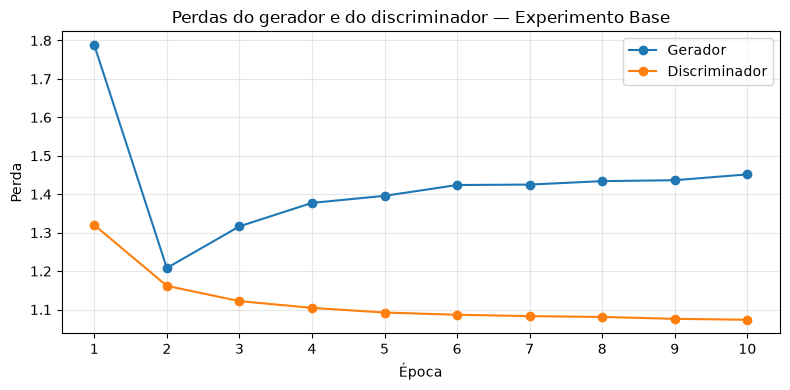

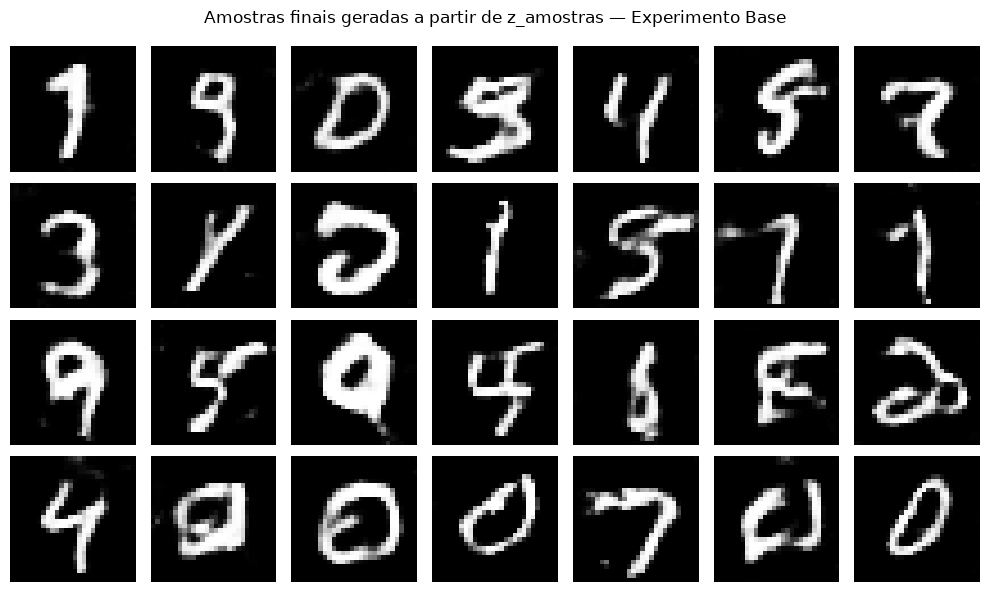

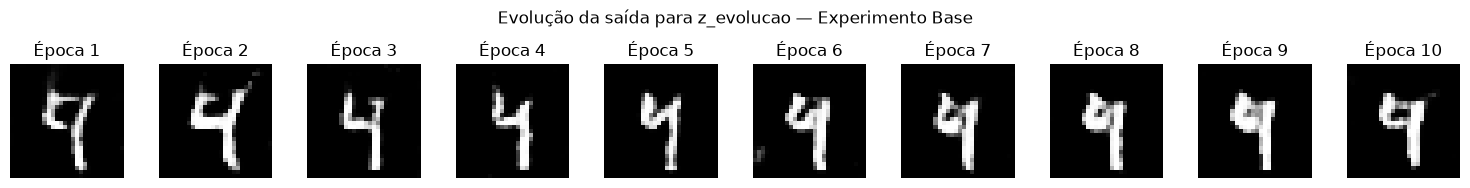

In [58]:
visualizar_resultado_experimento(resultados["base"])

### Visualização de todos os experimentos


Experimento: Gerador reduzido (gerador_reduzido)


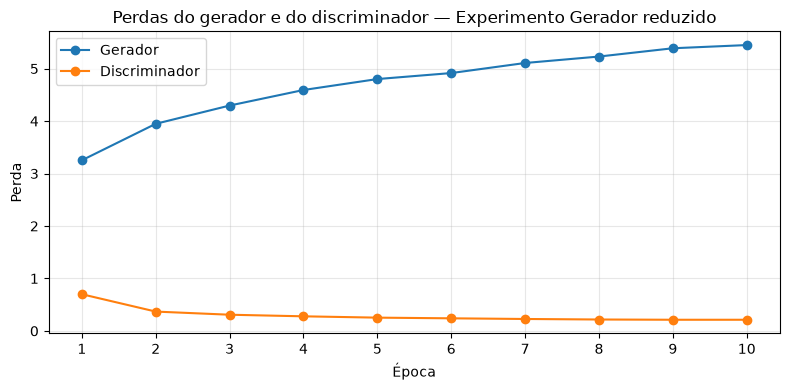

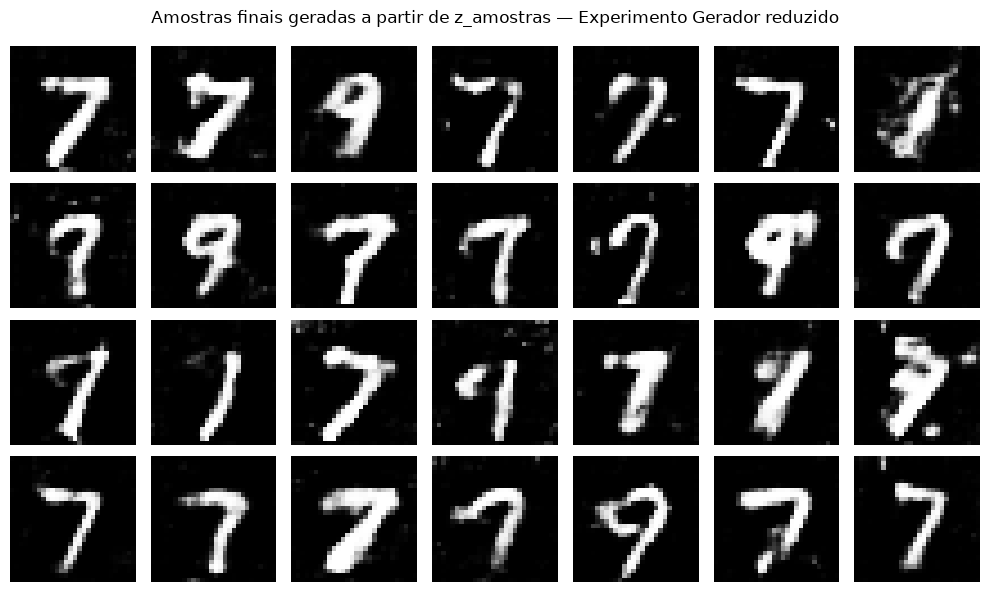

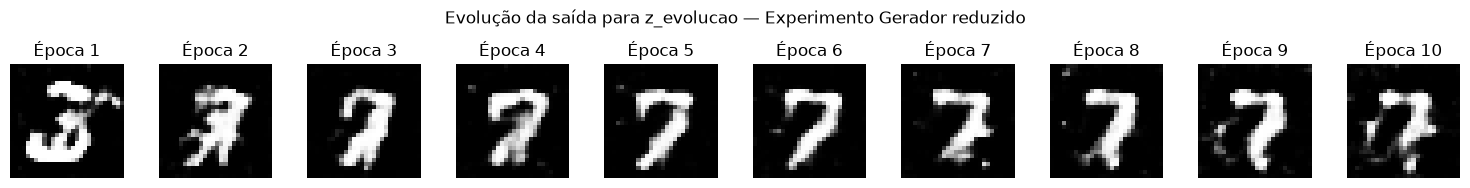


Experimento: Gerador ampliado (gerador_ampliado)


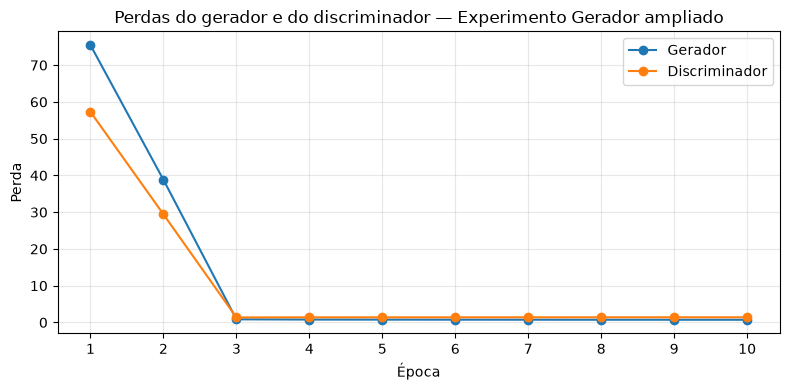

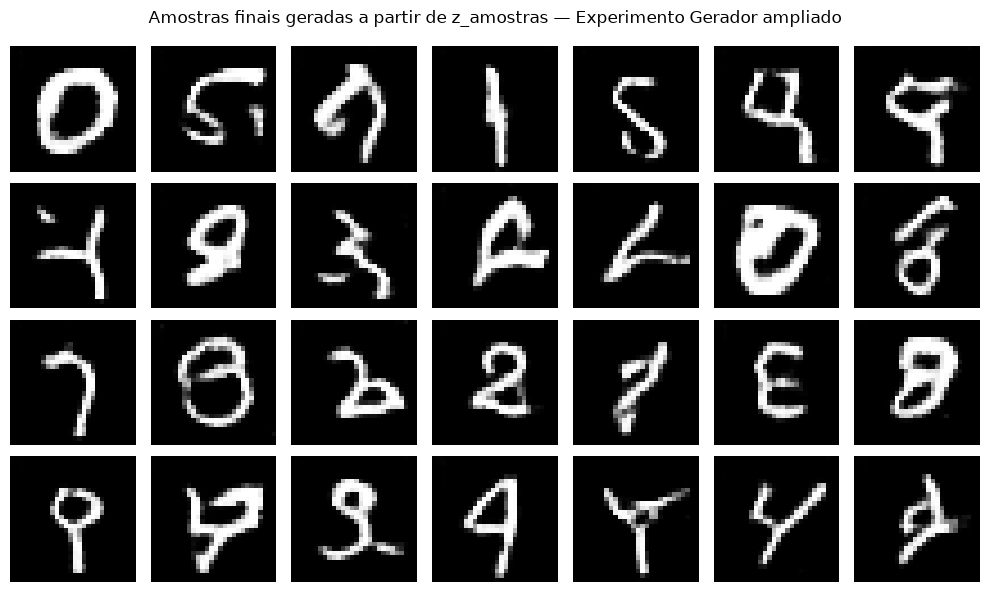

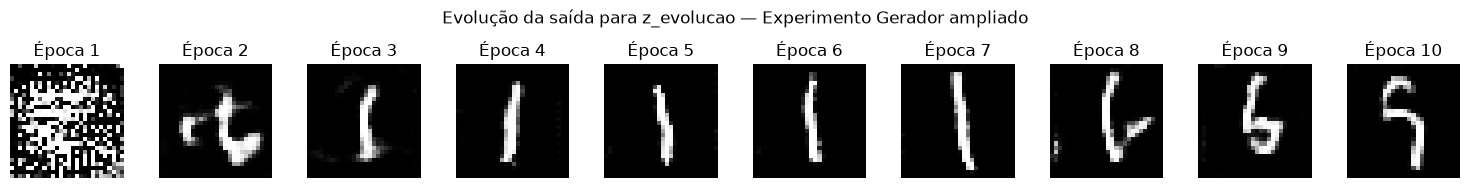


Experimento: Discriminador reduzido (discriminador_reduzido)


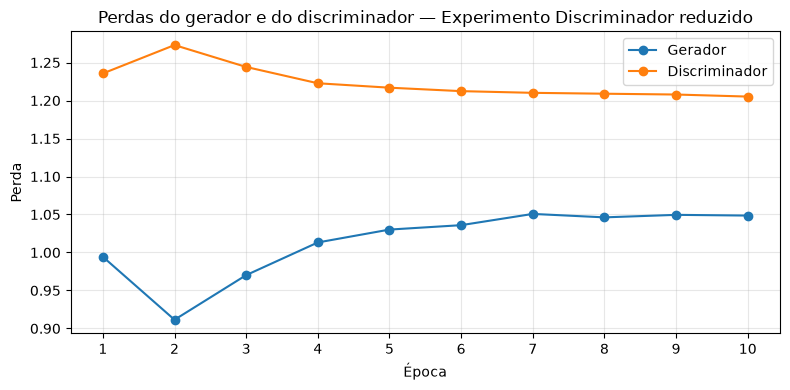

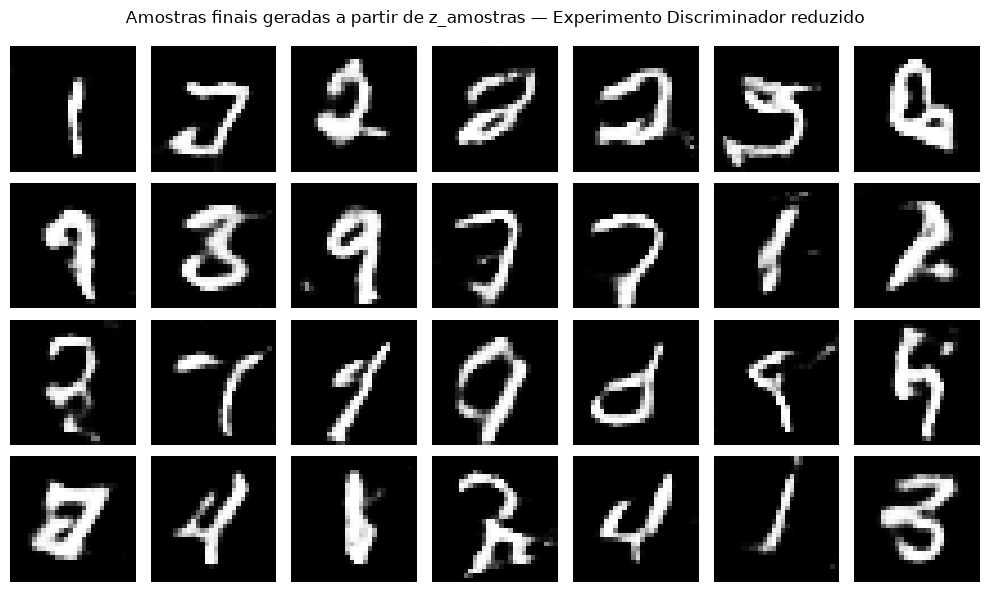

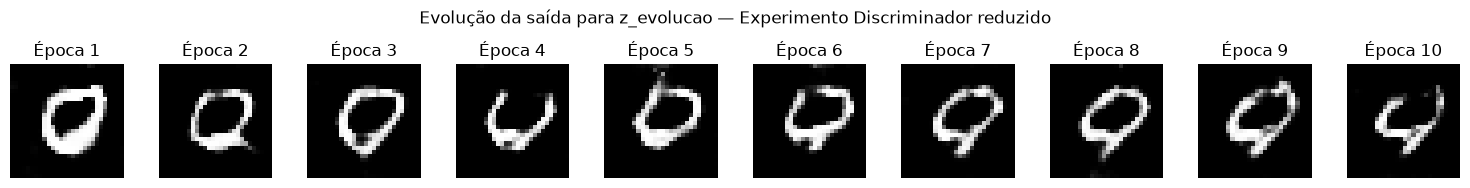


Experimento: Discriminador ampliado (discriminador_ampliado)


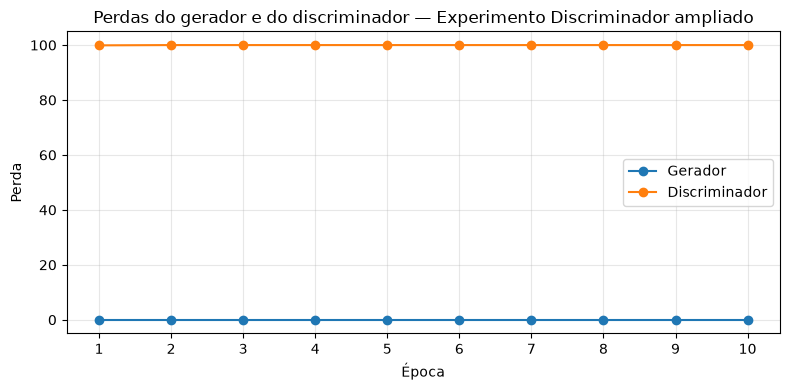

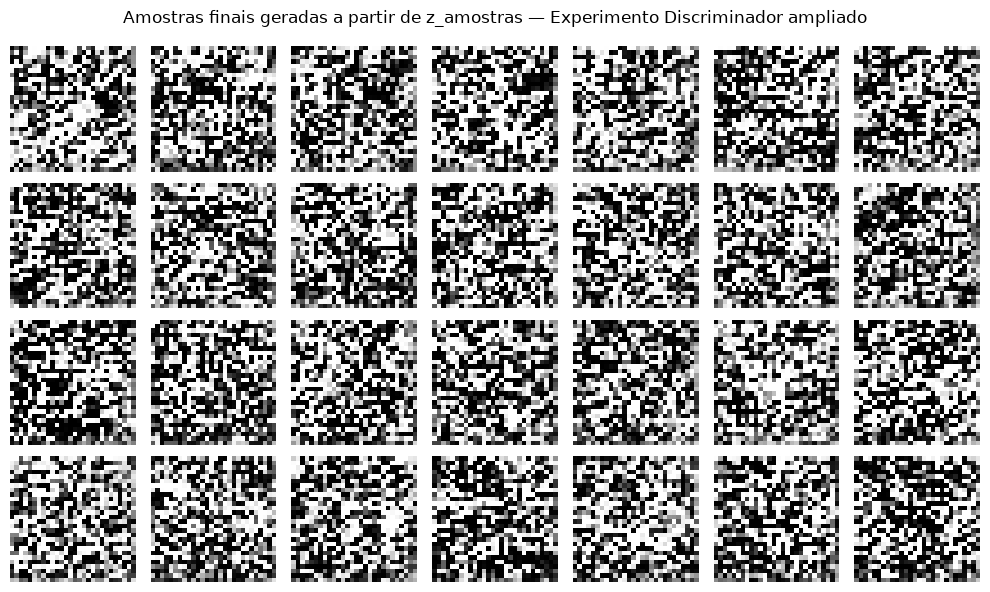

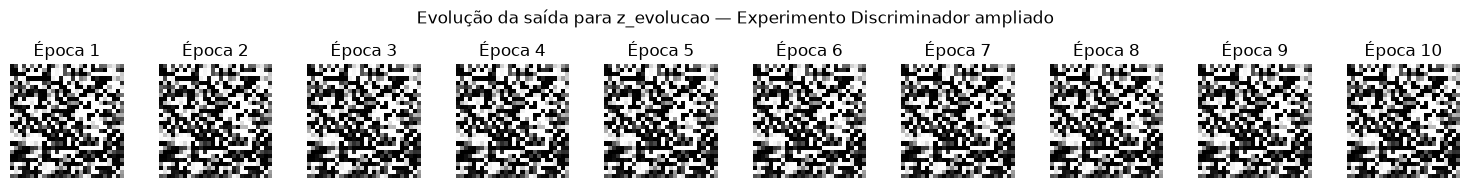


Experimento: Gerador e discriminador ampliados (ambos_ampliados)


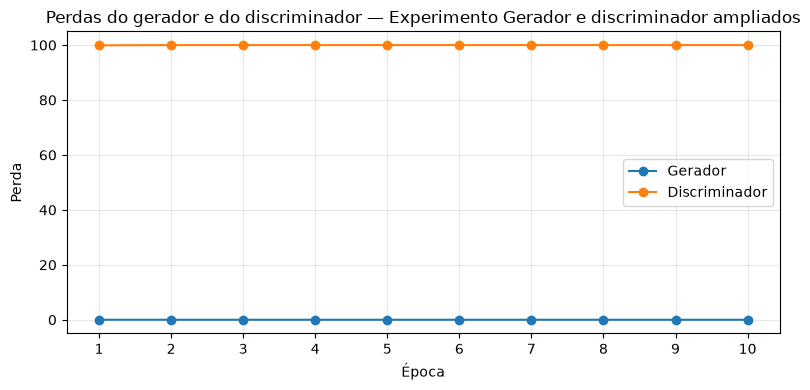

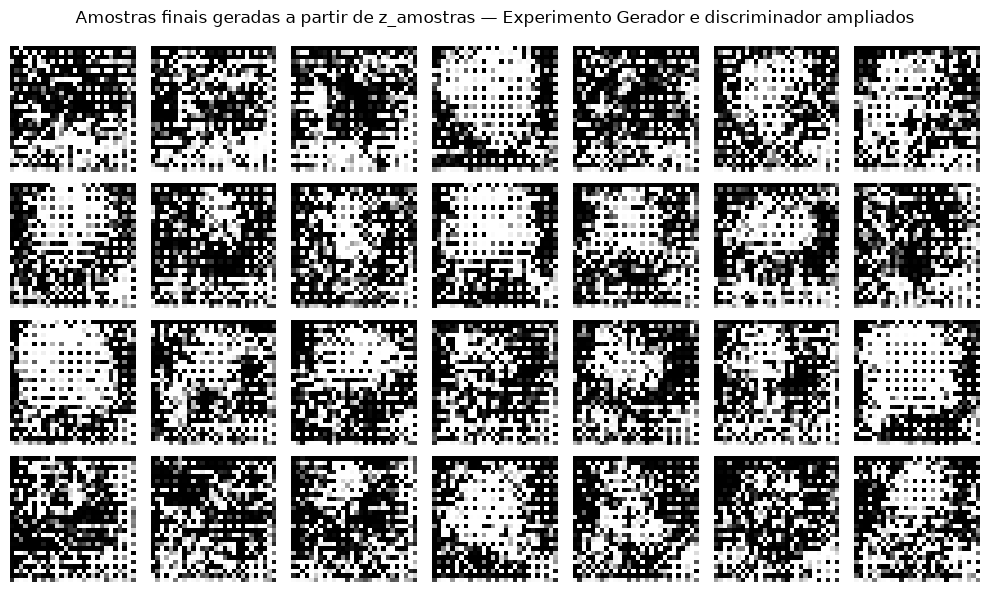

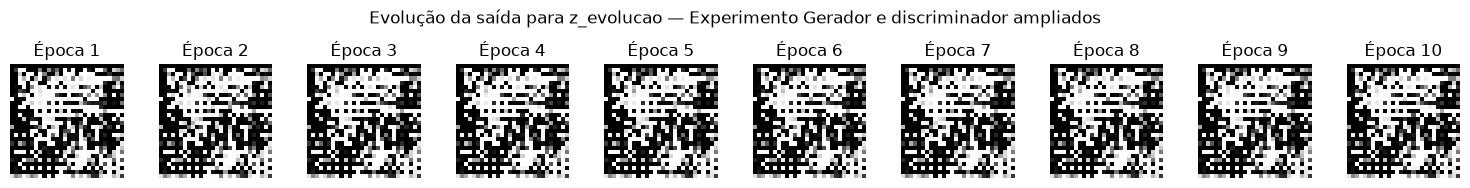


Experimento: LR gerador >> discriminador (lr_gerador_maior)


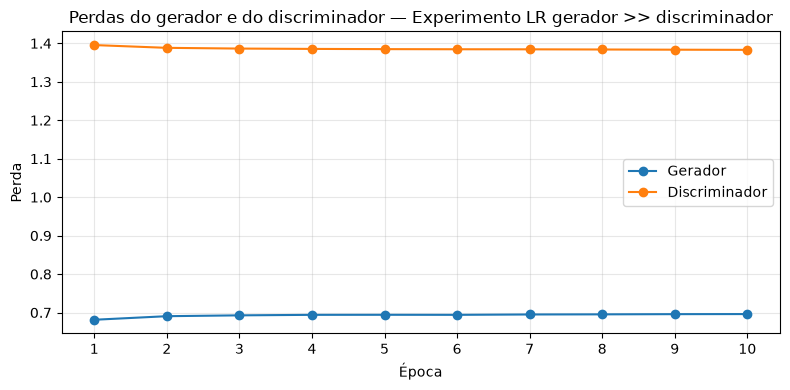

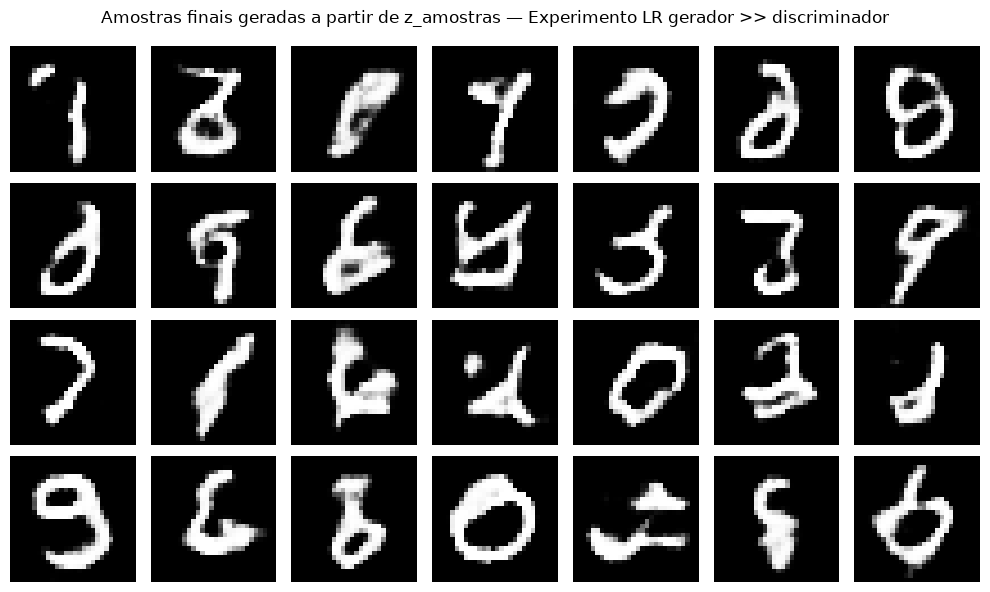

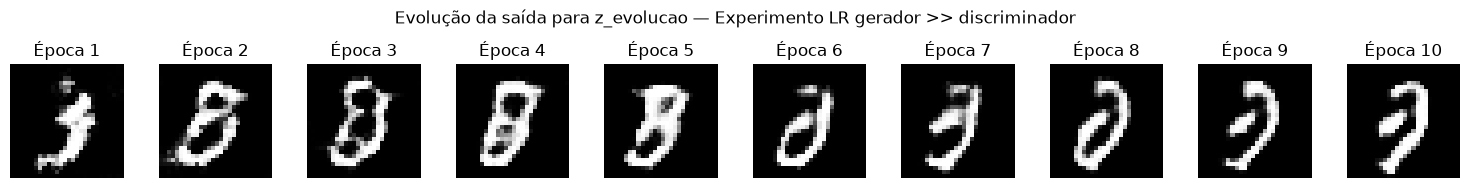


Experimento: LR gerador << discriminador (lr_discriminador_maior)


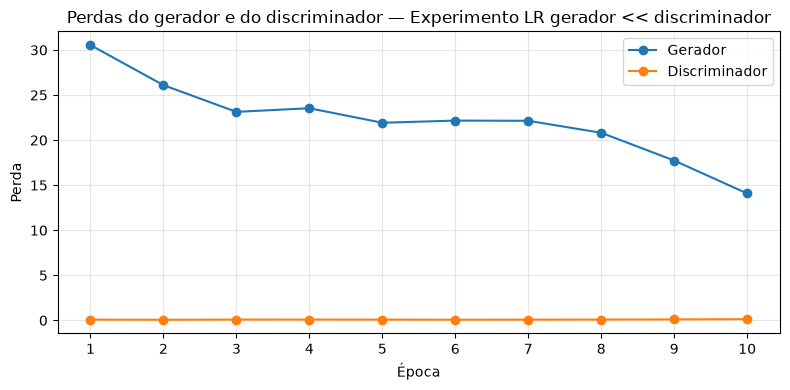

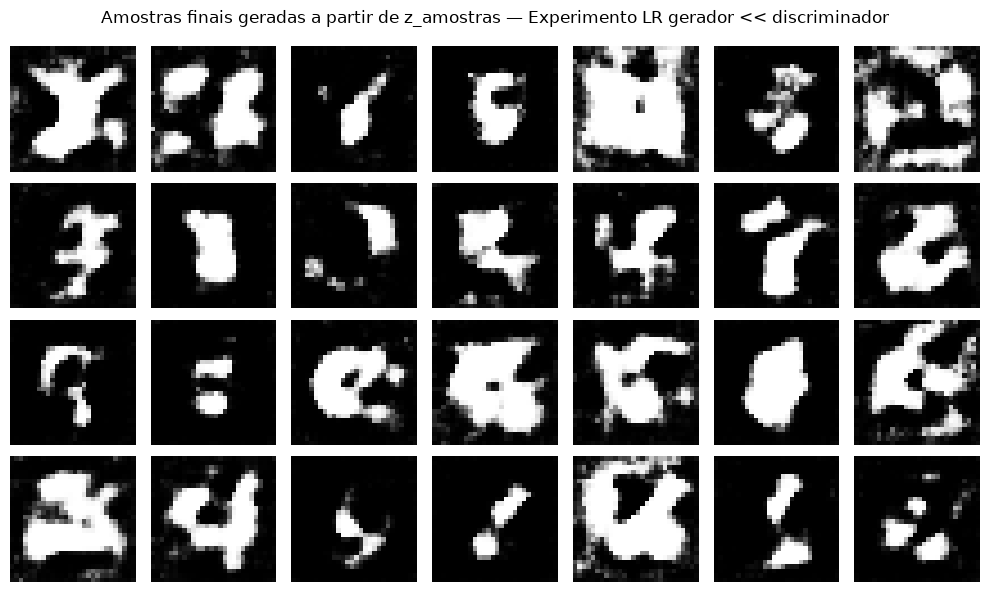

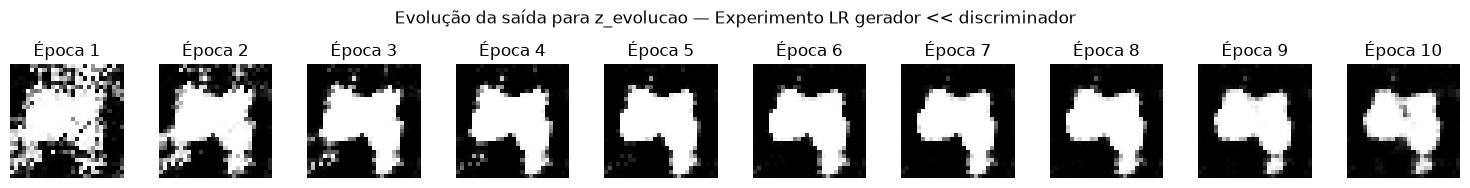


Experimento: LR ambos menores (lr_ambos_menores)


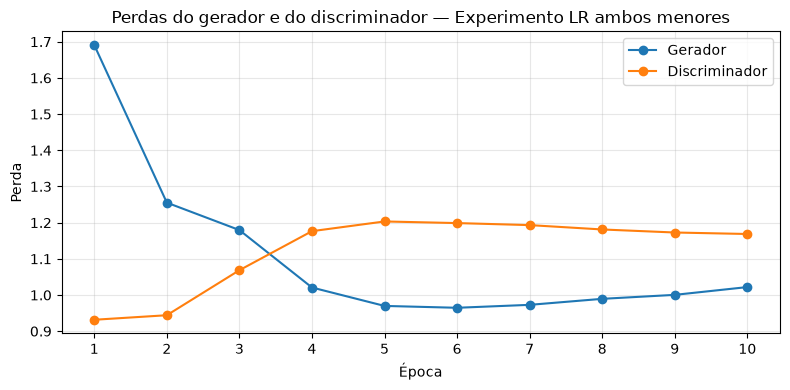

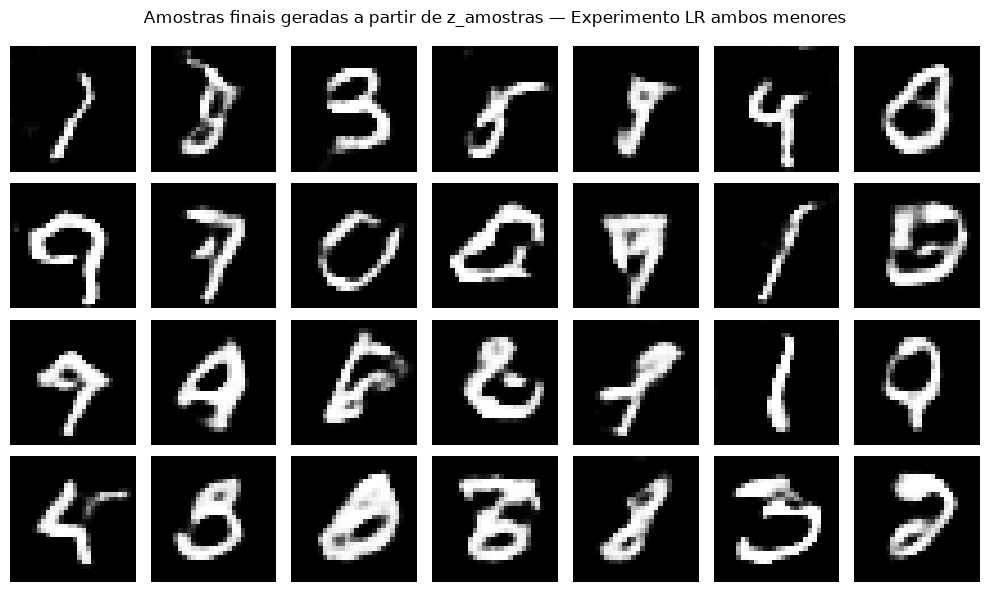

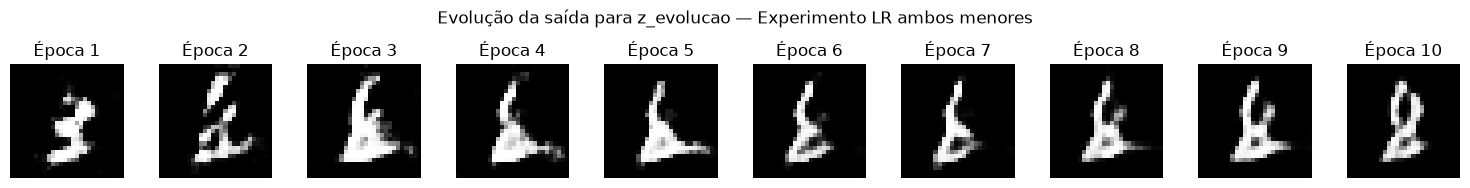


Experimento: SGD (sgd)


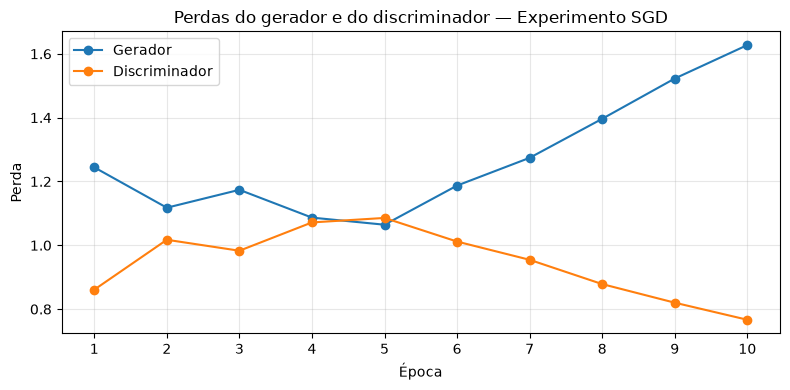

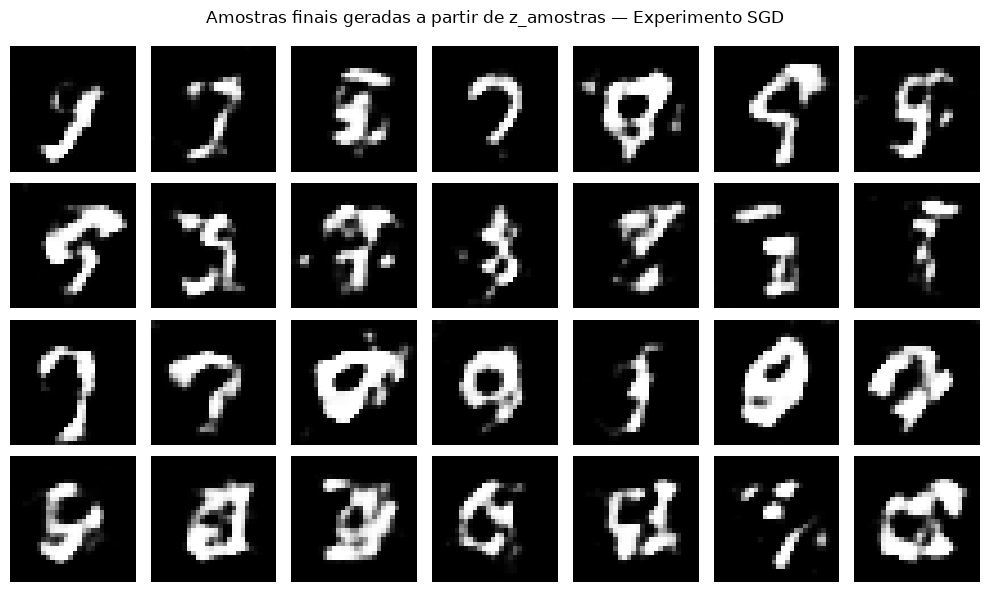

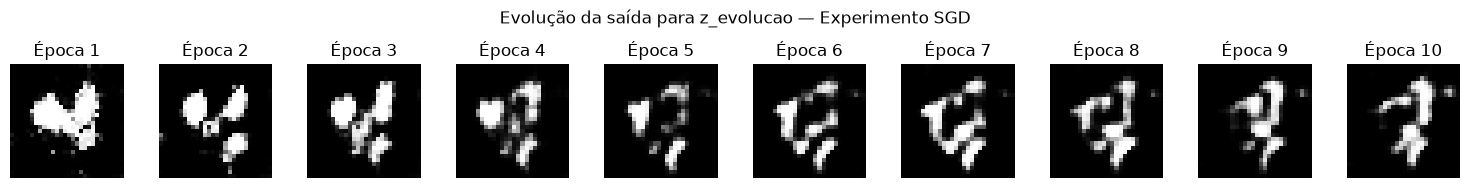

In [59]:
for id_experimento, resultado in resultados.items():

    # O experimento base ja foi visualizado na validação
    if id_experimento == "base":
        continue

    print()
    print("=" * 80)
    print(f"Experimento: {resultado['config']['nome']} ({id_experimento})")
    print("=" * 80)

    visualizar_resultado_experimento(resultado)

## Interpolações

### Reconstrução do gerador final

In [60]:
def carregar_gerador_final(id_experimento, config, device):
    caminhos = obter_caminhos_experimento(id_experimento)

    checkpoint = torch.load(
        caminhos["checkpoint_final"],
        map_location="cpu",
        weights_only=False
    )

    assert checkpoint["id_experimento"] == id_experimento
    assert checkpoint["config"] == config

    gerador = Gerador(**config["gerador"])
    gerador.load_state_dict(checkpoint["gerador_state_dict"])
    gerador = gerador.to(device)
    gerador.eval()

    return gerador

### Interpolação entre `z_interp_1` e `z_interp_2`

In [63]:
def interpolar_vetores_latentes(
    z_interp_1,
    z_interp_2,
    n_passos
):
    alphas = torch.linspace(
        0.0,
        1.0,
        steps=n_passos
    ).unsqueeze(1)

    return (
        (1.0 - alphas) * z_interp_1 +
        alphas * z_interp_2
    )

### Geração das imagens interpoladas

In [75]:
def gerar_interpolacao(
    gerador,
    z_interp_1,
    z_interp_2,
    n_passos,
    device
):
    z_interpolados = interpolar_vetores_latentes(
        z_interp_1=z_interp_1,
        z_interp_2=z_interp_2,
        n_passos=n_passos
    )

    imagens = gerar_saida(
        gerador=gerador,
        z=z_interpolados,
        device=device
    )

    return imagens

### Visualização da interpolação

In [74]:
def plotar_interpolacao(
    imagens,
    nome_experimento
):
    plt.figure(figsize=(20, 2))

    for indice, imagem in enumerate(imagens):
        plt.subplot(1, len(imagens), indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.axis("off")

    plt.suptitle(
        f"Interpolação entre z_interp_1 e z_interp_2 — Experimento {nome_experimento}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

### Validação com o experimento base

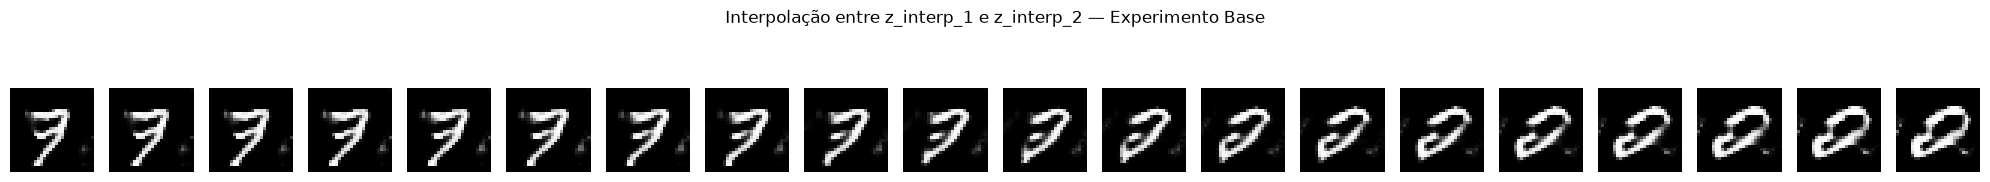

In [73]:
gerador_base = carregar_gerador_final(
    id_experimento="base",
    config=experimentos["base"],
    device=device
)

imagens_interpolacao_base = gerar_interpolacao(
    gerador=gerador_base,
    z_interp_1=z_interp_1,
    z_interp_2=z_interp_2,
    n_passos=n_passos_interpolacao,
    device=device
)

assert imagens_interpolacao_base.shape == (
    n_passos_interpolacao,
    1,
    28,
    28
)

assert imagens_interpolacao_base.device.type == "cpu"

plotar_interpolacao(
    imagens=imagens_interpolacao_base,
    nome_experimento=experimentos["base"]["nome"]
)

### Interpolação para todos os experimentos

In [78]:
interpolacoes = {}

for id_experimento, resultado in resultados.items():

    # O experimento base ja foi visualizado na validação
    if id_experimento == "base":
        continue
    
    gerador = carregar_gerador_final(
        id_experimento=id_experimento,
        config=resultado["config"],
        device=device
    )

    imagens_interpolacao = gerar_interpolacao(
        gerador=gerador,
        z_interp_1=z_interp_1,
        z_interp_2=z_interp_2,
        n_passos=n_passos_interpolacao,
        device=device
    )

    assert imagens_interpolacao.shape == (
        n_passos_interpolacao,
        1,
        28,
        28
    )

    assert imagens_interpolacao.device.type == "cpu"

    interpolacoes[id_experimento] = imagens_interpolacao

### Visualização das interpolações de todos os experimentos


Experimento: Gerador reduzido (gerador_reduzido)


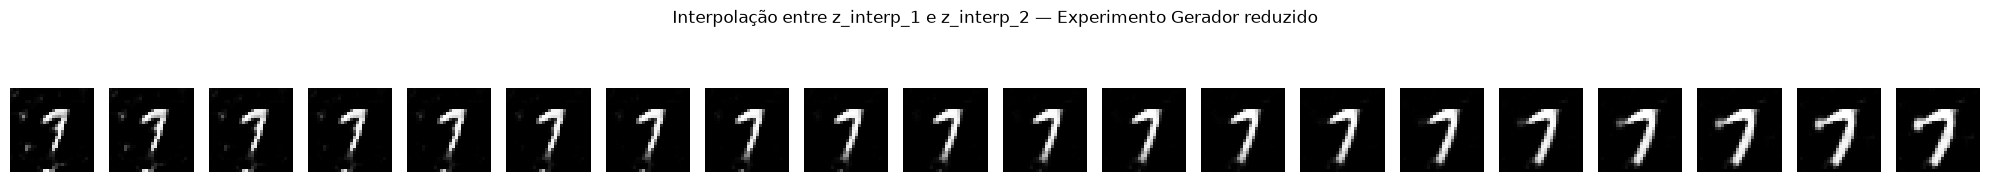


Experimento: Gerador ampliado (gerador_ampliado)


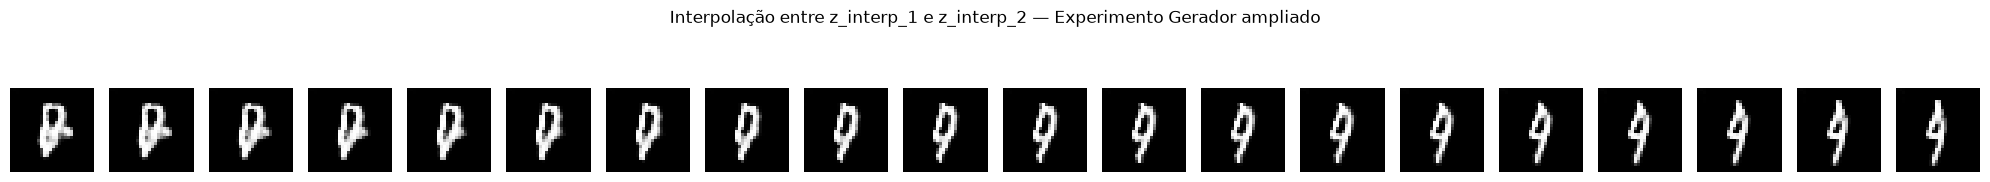


Experimento: Discriminador reduzido (discriminador_reduzido)


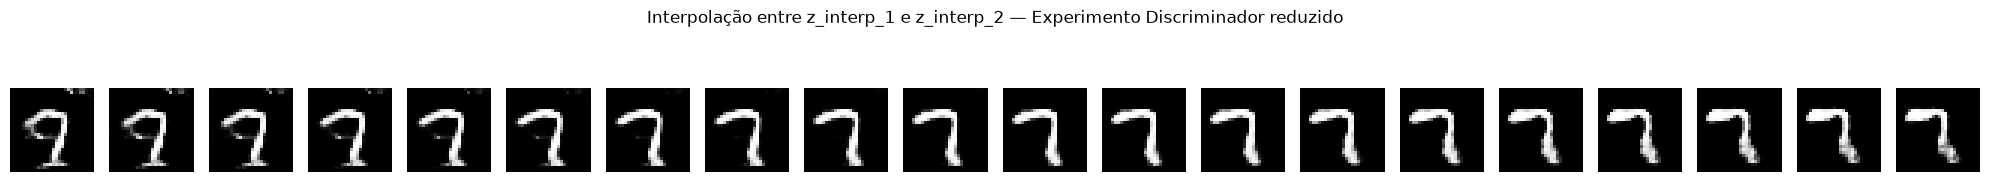


Experimento: Discriminador ampliado (discriminador_ampliado)


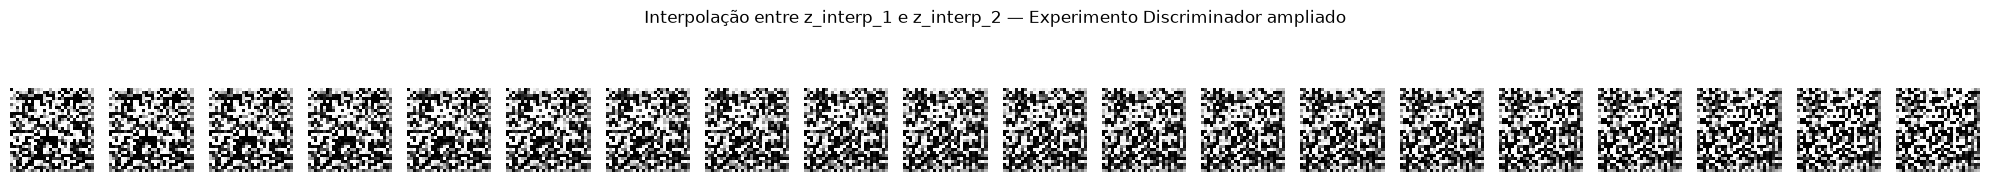


Experimento: Gerador e discriminador ampliados (ambos_ampliados)


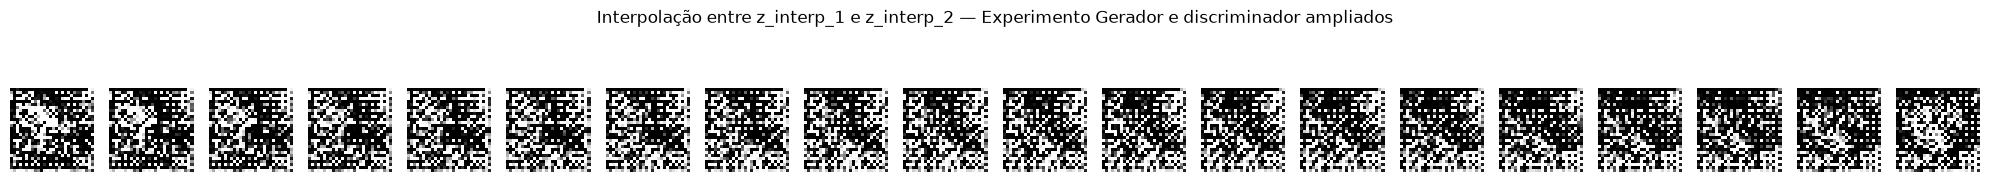


Experimento: LR gerador >> discriminador (lr_gerador_maior)


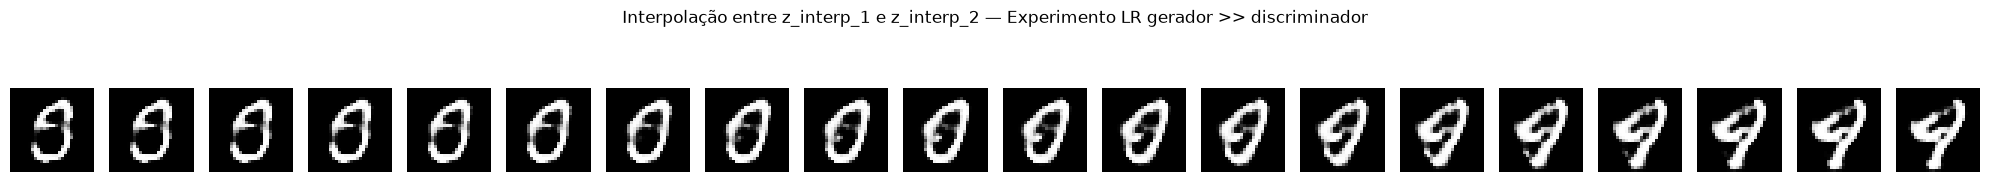


Experimento: LR gerador << discriminador (lr_discriminador_maior)


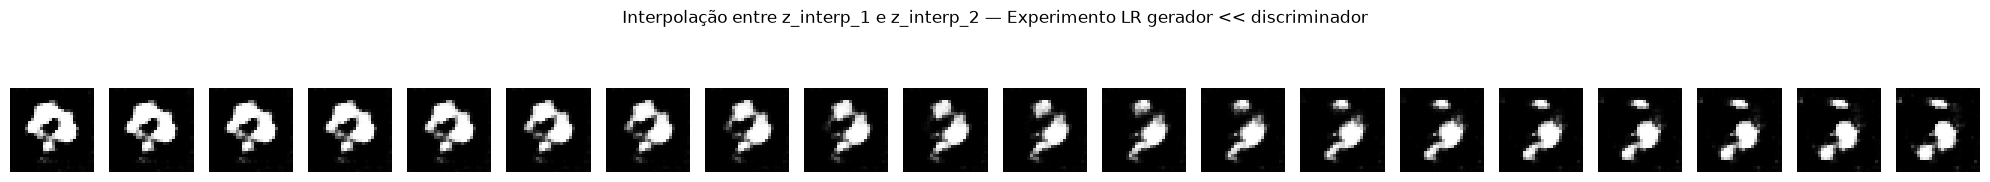


Experimento: LR ambos menores (lr_ambos_menores)


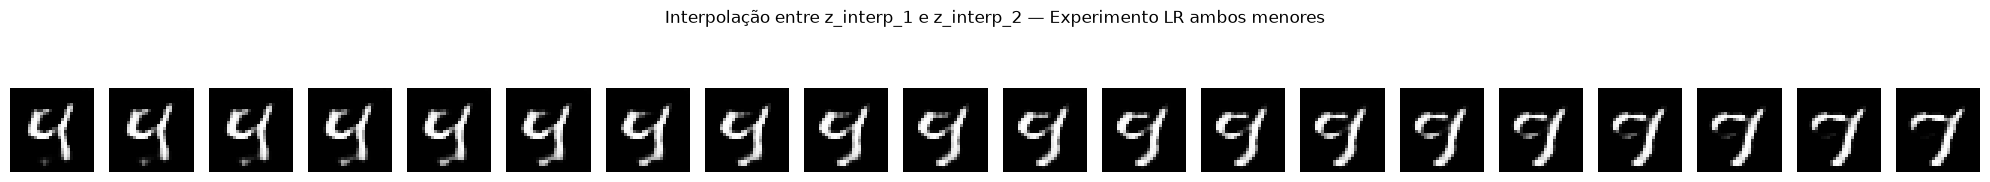


Experimento: SGD (sgd)


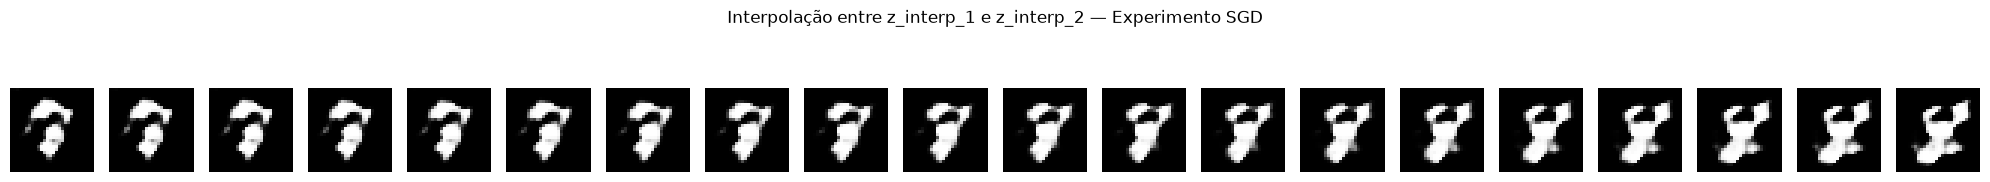

In [79]:
for id_experimento, imagens_interpolacao in interpolacoes.items():

    nome_experimento = resultados[id_experimento]["config"]["nome"]

    print()
    print("=" * 80)
    print(f"Experimento: {nome_experimento} ({id_experimento})")
    print("=" * 80)

    plotar_interpolacao(
        imagens=imagens_interpolacao,
        nome_experimento=nome_experimento
    )

## Resumo dos experimentos

### Criação de uma tabela resumindo os experimentos

In [83]:
def criar_tabela_resumo(resultados):
    linhas = []

    for id_experimento, resultado in resultados.items():
        config = resultado["config"]
        config_treinamento = config["treinamento"]
        historico = resultado["historico"]

        gerador = Gerador(**config["gerador"])
        discriminador = Discriminador(**config["discriminador"])

        linhas.append({
            "Experimento": config["nome"],
            "Parâmetros G": contar_parametros(gerador),
            "Parâmetros D": contar_parametros(discriminador),
            "Otimizador": config_treinamento["otimizador"],
            "LR G": config_treinamento["lr_gerador"],
            "LR D": config_treinamento["lr_discriminador"],
            "Loss G final": historico["loss_gerador"][-1],
            "Loss D final": historico["loss_discriminador"][-1],
            "Score reais final": historico["score_reais"][-1],
            "Score falsos final": historico["score_falsos"][-1]
        })

    return pd.DataFrame(linhas)

### Exibição do resumo dos experimentos

In [84]:
tabela_resumo = criar_tabela_resumo(resultados)

display(
    tabela_resumo.style
        .hide(axis="index")
        .format({
            "Parâmetros G": "{:,.0f}",
            "Parâmetros D": "{:,.0f}",
            "LR G": "{:.0e}",
            "LR D": "{:.0e}",
            "Loss G final": "{:.4f}",
            "Loss D final": "{:.4f}",
            "Score reais final": "{:.4f}",
            "Score falsos final": "{:.4f}"
        })
)

Experimento,Parâmetros G,Parâmetros D,Otimizador,LR G,LR D,Loss G final,Loss D final,Score reais final,Score falsos final
Base,"840,321","212,865",RMSprop,1e-03,1e-03,1.4517,1.0734,0.6620,0.3387
Gerador reduzido,"159,233","212,865",RMSprop,1e-03,1e-03,5.4494,0.2124,0.9500,0.0504
Gerador ampliado,"3,567,105","212,865",RMSprop,1e-03,1e-03,0.7260,1.3988,0.5044,0.4958
Discriminador reduzido,"840,321","42,225",RMSprop,1e-03,1e-03,1.0486,1.2052,0.5934,0.4064
Discriminador ampliado,"840,321","906,561",RMSprop,1e-03,1e-03,0.0000,100.0000,1.0000,1.0000
Gerador e discriminador ampliados,"3,567,105","906,561",RMSprop,1e-03,1e-03,0.0000,100.0000,1.0000,1.0000
LR gerador >> discriminador,"840,321","212,865",RMSprop,1e-03,1e-05,0.6961,1.3829,0.5012,0.4989
LR gerador << discriminador,"840,321","212,865",RMSprop,1e-05,1e-03,14.0794,0.1319,0.9742,0.0260
LR ambos menores,"840,321","212,865",RMSprop,1e-04,1e-04,1.0220,1.1687,0.5944,0.4070
SGD,"840,321","212,865",SGD,1e-03,1e-03,1.6274,0.7667,0.7298,0.2708
